In [1]:
# ============================================================
# 09 — Figure 1: Method workflow and approximation hierarchy
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


figure_dir = Path(
    "../figures/01_method_workflow"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    figure_dir.resolve()
)

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/01_method_workflow


# Figure 1 — Direct frequency-domain workflow and approximation hierarchy

This notebook constructs the conceptual overview figure for the manuscript.

Panel (a) summarizes the PULSUS direct frequency-domain workflow.

Panel (b) summarizes the controlled hierarchy of models:

- A: finite pulse + full interaction
- B: finite pulse + RWA
- C: short separated pulses + RWA
- D: impulsive RWA

The differences A-B, B-C, and C-D isolate distinct physical approximations.

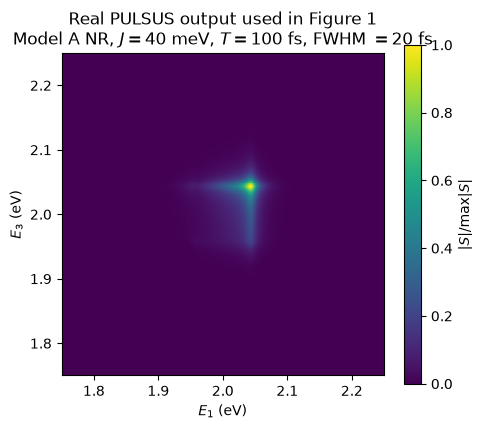

shape = (201, 201)
sigma = 12.011224087864498 fs
E0 = 0.066428247026796


In [1]:
# ============================================================
# Real PULSUS spectrum for the Figure 1 workflow
# ============================================================

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pulsus

# dimer_model.py lives in ../src
src_dir = Path("../src").resolve()

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from dimer_model import build_dimer


# ------------------------------------------------------------
# Physical units and representative dimer
# ------------------------------------------------------------

HBAR_EV_FS = 0.6582119569

E_center = 2.000       # eV
detuning = 0.040       # eV
J_eV = 0.040           # eV

E_a = E_center - detuning / 2
E_b = E_center + detuning / 2

gamma_a = 0.020        # fs^-1
gamma_b = 0.020        # fs^-1

nbar_a = 0.0
nbar_b = 0.0


# ------------------------------------------------------------
# Build the same physical dimer used in the sampling study
# ------------------------------------------------------------

model_fig1 = build_dimer(
    omega_a=E_a / HBAR_EV_FS,
    omega_b=E_b / HBAR_EV_FS,
    J=J_eV / HBAR_EV_FS,
    gamma_a=gamma_a,
    gamma_b=gamma_b,
    nbar_a=nbar_a,
    nbar_b=nbar_b,
    hbar=HBAR_EV_FS,
)

collapse_ops_fig1 = [
    model_fig1["L_a_down"],
    model_fig1["L_a_up"],
    model_fig1["L_b_down"],
    model_fig1["L_b_up"],
]

system_fig1 = pulsus.SpectroscopySystem(
    H=model_fig1["H_S"],
    dipole=model_fig1["mu"],
    collapse_ops=collapse_ops_fig1,
    rho0=model_fig1["rho0"],
    hbar=HBAR_EV_FS,
)


# ------------------------------------------------------------
# 20 fs intensity-FWHM Gaussian pulse
#
# C = (E0 / 2) sqrt(2 pi) sigma = 1
# ------------------------------------------------------------

FWHM_fig1 = 20.0

sigma_fig1 = (
    FWHM_fig1
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_fig1 = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma_fig1
    )
)

omega_L_fig1 = (
    E_center
    / HBAR_EV_FS
)

pulse_fig1 = pulsus.GaussianPulse(
    omega_L=omega_L_fig1,
    sigma=sigma_fig1,
    E0=E0_fig1,
    phase=0.0,
)


# ------------------------------------------------------------
# Direct frequency-domain spectrum
# ------------------------------------------------------------

T_fig1 = 100.0
eta_fig1 = 1.0e-10

E1_fig1 = np.linspace(
    1.75,
    2.25,
    201,
)

E3_fig1 = np.linspace(
    1.75,
    2.25,
    201,
)

S_fig1 = pulsus.finite_pulse_spectrum(
    system=system_fig1,
    pulse1=pulse_fig1,
    pulse2=pulse_fig1,
    pulse3=pulse_fig1,
    omega1=E1_fig1 / HBAR_EV_FS,
    omega3=E3_fig1 / HBAR_EV_FS,
    T=T_fig1,
    eta=eta_fig1,
    pathway="NR",
)

A_fig1 = (
    np.abs(S_fig1)
    / np.max(np.abs(S_fig1))
)


# ------------------------------------------------------------
# Inspect the real spectrum
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(5.2, 4.4)
)

im = ax.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax.set_xlabel(
    r"$E_1$ (eV)"
)

ax.set_ylabel(
    r"$E_3$ (eV)"
)

ax.set_title(
    "Real PULSUS output used in Figure 1\n"
    r"Model A NR, $J=40$ meV, $T=100$ fs, FWHM $=20$ fs"
)

cbar = fig.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    r"$|S|/\max|S|$"
)

plt.show()

print(
    "shape =",
    S_fig1.shape,
)

print(
    "sigma =",
    sigma_fig1,
    "fs",
)

print(
    "E0 =",
    E0_fig1,
)

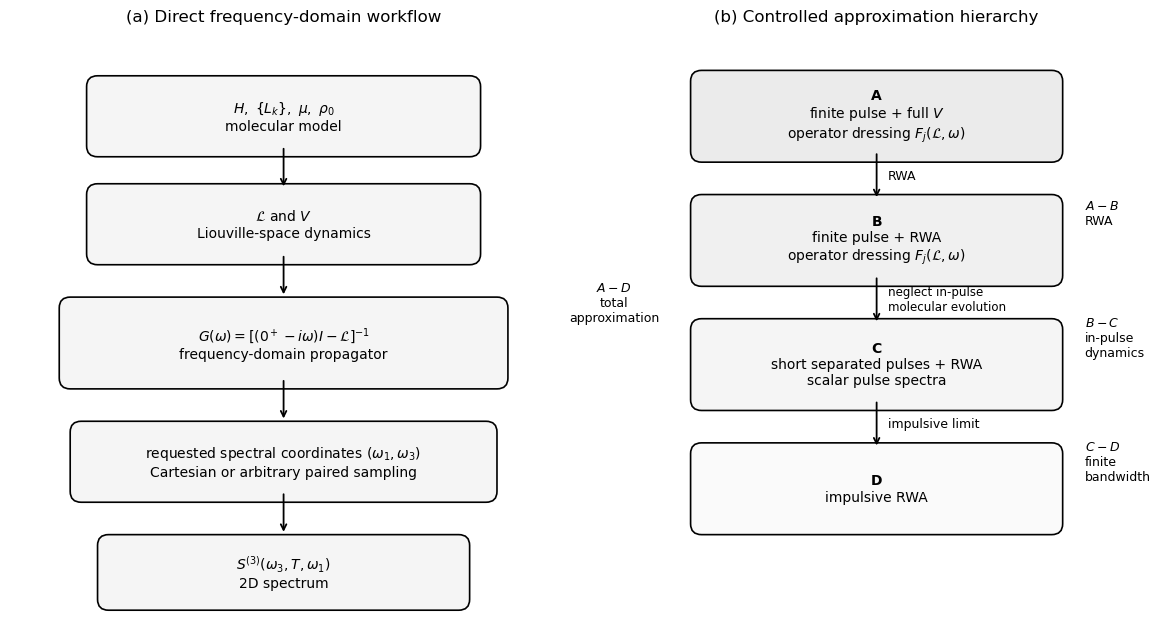

In [2]:
# ============================================================
# First draft of Figure 1
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 6.2),
    constrained_layout=True,
)

ax_workflow, ax_hierarchy = axes


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def draw_box(
    ax,
    x,
    y,
    width,
    height,
    text,
    fontsize=10,
    facecolor="0.96",
    linewidth=1.2,
):
    patch = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02",
        facecolor=facecolor,
        edgecolor="black",
        linewidth=linewidth,
    )

    ax.add_patch(
        patch
    )

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
    )

    return patch


def draw_arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    text=None,
    fontsize=9,
):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.3,
        ),
    )

    if text is not None:

        ax.text(
            (x1 + x2) / 2 + 0.02,
            (y1 + y2) / 2,
            text,
            fontsize=fontsize,
            va="center",
        )


# ============================================================
# Panel (a): direct frequency-domain workflow
# ============================================================

ax_workflow.set_title(
    "(a) Direct frequency-domain workflow",
    fontsize=12,
    pad=12,
)

draw_box(
    ax_workflow,
    0.16,
    0.80,
    0.68,
    0.11,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$"
    "\n"
    "molecular model",
)

draw_arrow(
    ax_workflow,
    0.50,
    0.80,
    0.50,
    0.72,
)

draw_box(
    ax_workflow,
    0.16,
    0.60,
    0.68,
    0.11,
    r"$\mathcal{L}$ and $V$"
    "\n"
    "Liouville-space dynamics",
)

draw_arrow(
    ax_workflow,
    0.50,
    0.60,
    0.50,
    0.52,
)

draw_box(
    ax_workflow,
    0.11,
    0.37,
    0.78,
    0.13,
    r"$G(\omega)=\left[(0^+-i\omega)I-\mathcal{L}\right]^{-1}$"
    "\n"
    "frequency-domain propagator",
)

draw_arrow(
    ax_workflow,
    0.50,
    0.37,
    0.50,
    0.29,
)

draw_box(
    ax_workflow,
    0.13,
    0.16,
    0.74,
    0.11,
    r"requested spectral coordinates $(\omega_1,\omega_3)$"
    "\n"
    "Cartesian or arbitrary paired sampling",
)

draw_arrow(
    ax_workflow,
    0.50,
    0.16,
    0.50,
    0.08,
)

draw_box(
    ax_workflow,
    0.18,
    -0.04,
    0.64,
    0.10,
    r"$S^{(3)}(\omega_3,T,\omega_1)$"
    "\n"
    "2D spectrum",
)


# ============================================================
# Panel (b): approximation hierarchy
# ============================================================

ax_hierarchy.set_title(
    "(b) Controlled approximation hierarchy",
    fontsize=12,
    pad=12,
)


# Model A
draw_box(
    ax_hierarchy,
    0.18,
    0.79,
    0.64,
    0.13,
    r"$\mathbf{A}$"
    "\n"
    "finite pulse + full $V$"
    "\n"
    r"operator dressing $F_j(\mathcal{L},\omega)$",
    facecolor="0.92",
)

draw_arrow(
    ax_hierarchy,
    0.50,
    0.79,
    0.50,
    0.70,
    text="RWA",
)


# Model B
draw_box(
    ax_hierarchy,
    0.18,
    0.56,
    0.64,
    0.13,
    r"$\mathbf{B}$"
    "\n"
    "finite pulse + RWA"
    "\n"
    r"operator dressing $F_j(\mathcal{L},\omega)$",
    facecolor="0.94",
)

draw_arrow(
    ax_hierarchy,
    0.50,
    0.56,
    0.50,
    0.47,
    text="neglect in-pulse"
    "\n"
    "molecular evolution",
    fontsize=8.5,
)


# Model C
draw_box(
    ax_hierarchy,
    0.18,
    0.33,
    0.64,
    0.13,
    r"$\mathbf{C}$"
    "\n"
    "short separated pulses + RWA"
    "\n"
    "scalar pulse spectra",
    facecolor="0.96",
)

draw_arrow(
    ax_hierarchy,
    0.50,
    0.33,
    0.50,
    0.24,
    text="impulsive limit",
)


# Model D
draw_box(
    ax_hierarchy,
    0.18,
    0.10,
    0.64,
    0.13,
    r"$\mathbf{D}$"
    "\n"
    "impulsive RWA",
    facecolor="0.98",
)


# ------------------------------------------------------------
# Error labels
# ------------------------------------------------------------

ax_hierarchy.text(
    0.88,
    0.675,
    r"$A-B$"
    "\n"
    "RWA",
    fontsize=9,
    va="center",
)

ax_hierarchy.text(
    0.88,
    0.445,
    r"$B-C$"
    "\n"
    "in-pulse"
    "\n"
    "dynamics",
    fontsize=9,
    va="center",
)

ax_hierarchy.text(
    0.88,
    0.215,
    r"$C-D$"
    "\n"
    "finite"
    "\n"
    "bandwidth",
    fontsize=9,
    va="center",
)

ax_hierarchy.text(
    0.02,
    0.51,
    r"$A-D$"
    "\n"
    "total"
    "\n"
    "approximation",
    fontsize=9,
    ha="center",
    va="center",
)


# ============================================================
# Remove ordinary axes
# ============================================================

for ax in axes:

    ax.set_xlim(
        0,
        1,
    )

    ax.set_ylim(
        -0.08,
        1,
    )

    ax.axis(
        "off"
    )


plt.show()

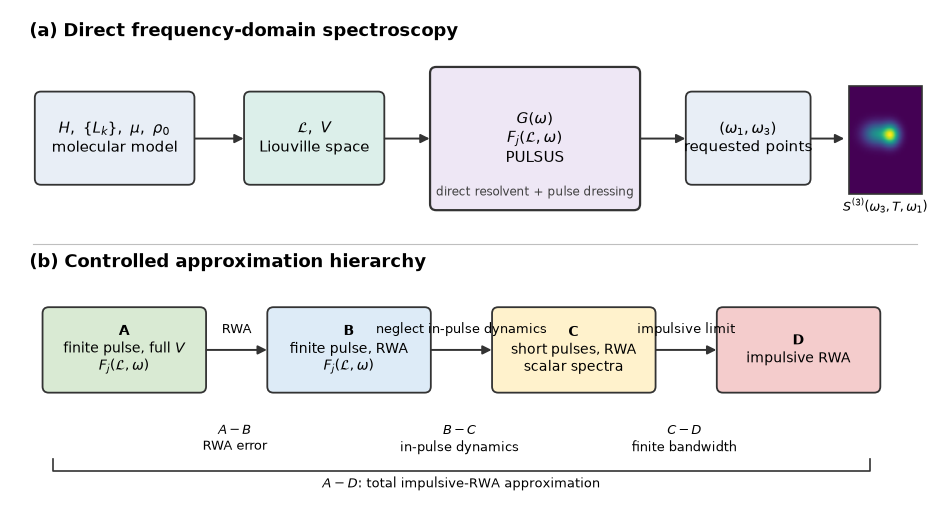

In [2]:
# ============================================================
# Figure 1 — Integrated PULSUS workflow + approximation ladder
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Rectangle,
)

fig, ax = plt.subplots(
    figsize=(12.0, 6.4)
)

ax.set_xlim(0, 12)
ax.set_ylim(0, 6.4)
ax.axis("off")


# ------------------------------------------------------------
# Palette
# ------------------------------------------------------------

c_input = "#E8EEF6"
c_core = "#DCEFEA"
c_freq = "#EEE7F5"
c_output = "#F8ECD9"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"

edge = "#333333"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def rounded_box(
    x,
    y,
    w,
    h,
    text,
    facecolor,
    fontsize=10,
    lw=1.3,
):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=lw,
    )

    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
    )

    return box


def arrow(
    x1,
    y1,
    x2,
    y2,
    text=None,
    text_y_offset=0.18,
):
    a = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=13,
        linewidth=1.4,
        color=edge,
    )

    ax.add_patch(a)

    if text is not None:
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + text_y_offset,
            text,
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ============================================================
# TOP: PULSUS workflow
# ============================================================

ax.text(
    0.25,
    6.05,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=13,
    weight="bold",
    ha="left",
)


# ------------------------------------------------------------
# Input model
# ------------------------------------------------------------

rounded_box(
    0.35,
    4.15,
    2.0,
    1.15,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$"
    "\n"
    "molecular model",
    c_input,
    fontsize=11,
)

arrow(
    2.35,
    4.72,
    3.05,
    4.72,
)


# ------------------------------------------------------------
# Liouville-space construction
# ------------------------------------------------------------

rounded_box(
    3.05,
    4.15,
    1.75,
    1.15,
    r"$\mathcal{L},\ V$"
    "\n"
    "Liouville space",
    c_core,
    fontsize=11,
)

arrow(
    4.80,
    4.72,
    5.45,
    4.72,
)


# ------------------------------------------------------------
# PULSUS frequency-domain engine
# ------------------------------------------------------------

rounded_box(
    5.45,
    3.82,
    2.65,
    1.80,
    r"$G(\omega)$"
    "\n"
    r"$F_j(\mathcal{L},\omega)$"
    "\n"
    "PULSUS",
    c_freq,
    fontsize=11,
    lw=1.6,
)

ax.text(
    6.775,
    3.98,
    "direct resolvent + pulse dressing",
    fontsize=8.5,
    ha="center",
    color="0.25",
)

arrow(
    8.10,
    4.72,
    8.75,
    4.72,
)


# ------------------------------------------------------------
# Requested spectral coordinates
# ------------------------------------------------------------

rounded_box(
    8.75,
    4.15,
    1.55,
    1.15,
    r"$(\omega_1,\omega_3)$"
    "\n"
    "requested points",
    c_input,
    fontsize=10.5,
)

arrow(
    10.30,
    4.72,
    10.80,
    4.72,
)


# ------------------------------------------------------------
# Schematic output spectrum
# ------------------------------------------------------------

x0, y0 = 10.82, 4.00
w, h = 0.95, 1.40

nx = 80
ny = 80

xx = np.linspace(-1, 1, nx)
yy = np.linspace(-1, 1, ny)

X, Y = np.meshgrid(
    xx,
    yy,
)

Z = (
    np.exp(
        -(
            (X - 0.15) ** 2 / 0.05
            + (Y - 0.10) ** 2 / 0.035
        )
    )
    + 0.55
    * np.exp(
        -(
            (X + 0.25) ** 2 / 0.12
            + (Y - 0.12) ** 2 / 0.04
        )
    )
)

ax.imshow(
    Z,
    extent=[
        x0,
        x0 + w,
        y0,
        y0 + h,
    ],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)

ax.add_patch(
    Rectangle(
        (x0, y0),
        w,
        h,
        fill=False,
        edgecolor=edge,
        linewidth=1.2,
    )
)

ax.text(
    x0 + w / 2,
    3.78,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=9,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [0.3, 11.7],
    [3.35, 3.35],
    linewidth=0.8,
    color="0.75",
)


# ============================================================
# BOTTOM: approximation hierarchy
# ============================================================

ax.text(
    0.25,
    3.05,
    "(b) Controlled approximation hierarchy",
    fontsize=13,
    weight="bold",
    ha="left",
)


# ------------------------------------------------------------
# Models A-D
# ------------------------------------------------------------

box_y = 1.45
box_w = 2.05
box_h = 1.05

xA = 0.45
xB = 3.35
xC = 6.25
xD = 9.15


rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    r"$\mathbf{A}$"
    "\n"
    "finite pulse, full $V$"
    "\n"
    r"$F_j(\mathcal{L},\omega)$",
    c_A,
    fontsize=10,
)

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    r"$\mathbf{B}$"
    "\n"
    "finite pulse, RWA"
    "\n"
    r"$F_j(\mathcal{L},\omega)$",
    c_B,
    fontsize=10,
)

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    r"$\mathbf{C}$"
    "\n"
    "short pulses, RWA"
    "\n"
    "scalar spectra",
    c_C,
    fontsize=10,
)

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    r"$\mathbf{D}$"
    "\n"
    "impulsive RWA",
    c_D,
    fontsize=10,
)


# ------------------------------------------------------------
# Approximation arrows
# ------------------------------------------------------------

arrow(
    xA + box_w,
    box_y + box_h / 2,
    xB,
    box_y + box_h / 2,
    text="RWA",
)

arrow(
    xB + box_w,
    box_y + box_h / 2,
    xC,
    box_y + box_h / 2,
    text="neglect in-pulse dynamics",
)

arrow(
    xC + box_w,
    box_y + box_h / 2,
    xD,
    box_y + box_h / 2,
    text="impulsive limit",
)


# ------------------------------------------------------------
# What each difference isolates
# ------------------------------------------------------------

ax.text(
    2.90,
    1.02,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    va="top",
    fontsize=9,
)

ax.text(
    5.80,
    1.02,
    r"$B-C$"
    "\n"
    "in-pulse dynamics",
    ha="center",
    va="top",
    fontsize=9,
)

ax.text(
    8.70,
    1.02,
    r"$C-D$"
    "\n"
    "finite bandwidth",
    ha="center",
    va="top",
    fontsize=9,
)


# ------------------------------------------------------------
# A-D bracket
# ------------------------------------------------------------

y_bracket = 0.40

ax.plot(
    [
        xA + 0.1,
        xA + 0.1,
        xD + box_w - 0.1,
        xD + box_w - 0.1,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    y_bracket - 0.08,
    r"$A-D$: total impulsive-RWA approximation",
    ha="center",
    va="top",
    fontsize=9.5,
)


plt.show()

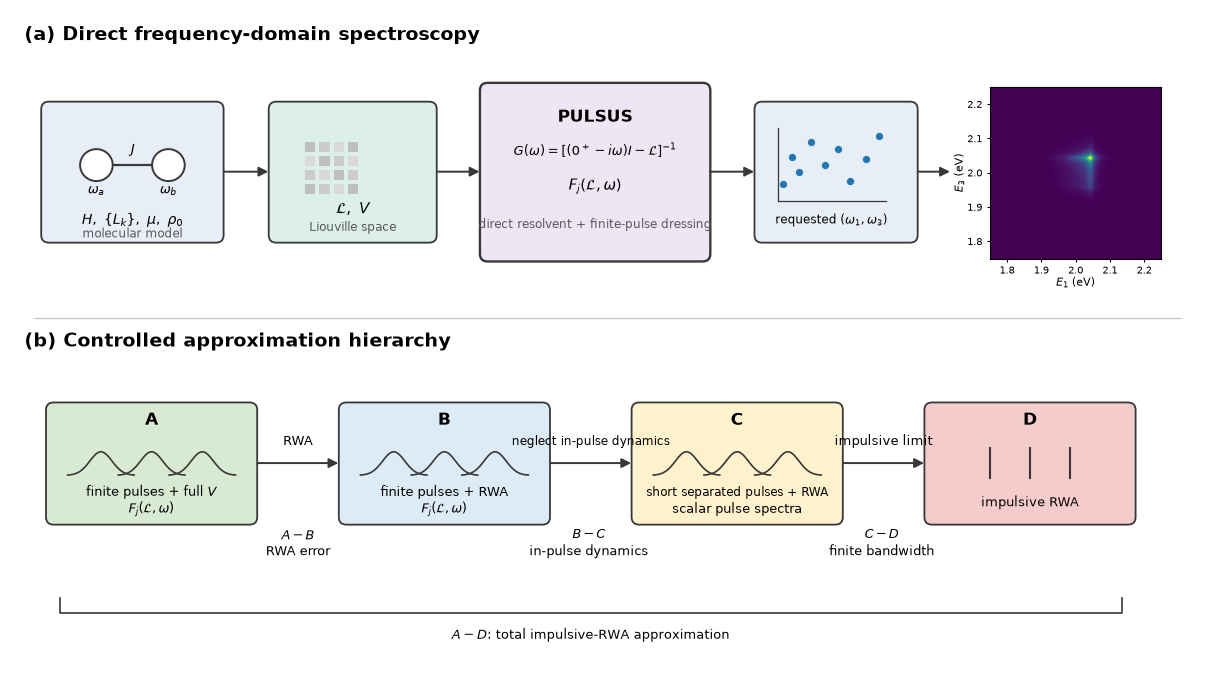

In [3]:
# ============================================================
# Figure 1 — Graphical PULSUS overview
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Rectangle,
)


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(12.5, 7.0)
)

ax = fig.add_axes(
    [0.02, 0.03, 0.96, 0.94]
)

ax.set_xlim(0, 12.5)
ax.set_ylim(0, 7.0)
ax.axis("off")


# ============================================================
# Colors
# ============================================================

edge = "0.22"

c_model = "#E7EEF7"
c_liouville = "#DDEFEA"
c_pulsus = "#EEE6F5"
c_sampling = "#E8EEF6"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"


# ============================================================
# Helper functions
# ============================================================

def arrow(
    x1,
    y1,
    x2,
    y2,
    text=None,
    text_offset=0.18,
    fontsize=9,
):

    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.4,
        color=edge,
    )

    ax.add_patch(
        patch
    )

    if text is not None:

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + text_offset,
            text,
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def rounded_box(
    x,
    y,
    w,
    h,
    facecolor,
    linewidth=1.3,
):

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.025,rounding_size=0.08",
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=linewidth,
    )

    ax.add_patch(
        box
    )

    return box


def draw_gaussian_pulses(
    x0,
    y0,
    width,
    height,
):

    x = np.linspace(
        -3.0,
        3.0,
        100,
    )

    centers = [
        0.18,
        0.50,
        0.82,
    ]

    for center in centers:

        xx = (
            x0
            + center * width
            + 0.07 * width * x
        )

        yy = (
            y0
            + height
            * np.exp(
                -0.5 * x**2
            )
        )

        ax.plot(
            xx,
            yy,
            linewidth=1.2,
            color=edge,
        )


def draw_impulses(
    x0,
    y0,
    width,
    height,
):

    for frac in [
        0.25,
        0.50,
        0.75,
    ]:

        x = (
            x0
            + frac * width
        )

        ax.plot(
            [x, x],
            [
                y0,
                y0 + height,
            ],
            linewidth=1.5,
            color=edge,
        )


# ============================================================
# PANEL (a)
# ============================================================

ax.text(
    0.15,
    6.68,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ------------------------------------------------------------
# 1. Coupled molecular system
# ------------------------------------------------------------

rounded_box(
    0.35,
    4.55,
    1.85,
    1.45,
    c_model,
)

# two coupled sites
site_y = 5.35

ax.add_patch(
    Circle(
        (0.90, site_y),
        0.17,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.4,
    )
)

ax.add_patch(
    Circle(
        (1.65, site_y),
        0.17,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.4,
    )
)

ax.plot(
    [
        1.07,
        1.48,
    ],
    [
        site_y,
        site_y,
    ],
    linewidth=1.6,
    color=edge,
)

ax.text(
    1.28,
    site_y + 0.12,
    r"$J$",
    ha="center",
    fontsize=9,
)

ax.text(
    0.90,
    5.05,
    r"$\omega_a$",
    ha="center",
    fontsize=9,
)

ax.text(
    1.65,
    5.05,
    r"$\omega_b$",
    ha="center",
    fontsize=9,
)

ax.text(
    1.275,
    4.72,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$",
    ha="center",
    fontsize=10,
)

ax.text(
    1.275,
    4.58,
    "molecular model",
    ha="center",
    fontsize=8.5,
    color="0.35",
)


arrow(
    2.20,
    5.28,
    2.72,
    5.28,
)


# ------------------------------------------------------------
# 2. Liouville-space representation
# ------------------------------------------------------------

rounded_box(
    2.72,
    4.55,
    1.70,
    1.45,
    c_liouville,
)

# matrix icon
mx0 = 3.07
my0 = 5.04

for i in range(4):

    for j in range(4):

        shade = (
            0.75
            + 0.05
            * ((i + j) % 3)
        )

        ax.add_patch(
            Rectangle(
                (
                    mx0 + 0.15 * j,
                    my0 + 0.15 * i,
                ),
                0.11,
                0.11,
                facecolor=str(shade),
                edgecolor="none",
            )
        )

ax.text(
    3.57,
    4.83,
    r"$\mathcal{L},\ V$",
    ha="center",
    fontsize=11,
)

ax.text(
    3.57,
    4.65,
    "Liouville space",
    ha="center",
    fontsize=8.5,
    color="0.35",
)


arrow(
    4.42,
    5.28,
    4.92,
    5.28,
)


# ------------------------------------------------------------
# 3. PULSUS engine
# ------------------------------------------------------------

rounded_box(
    4.92,
    4.35,
    2.35,
    1.85,
    c_pulsus,
    linewidth=1.7,
)

ax.text(
    6.095,
    5.86,
    "PULSUS",
    ha="center",
    va="center",
    fontsize=12.5,
    weight="bold",
)

ax.text(
    6.095,
    5.45,
    r"$G(\omega)"
    r"=[(0^+-i\omega)I-\mathcal{L}]^{-1}$",
    ha="center",
    fontsize=9.5,
)

ax.text(
    6.095,
    5.08,
    r"$F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=10.5,
)

ax.text(
    6.095,
    4.68,
    "direct resolvent + finite-pulse dressing",
    ha="center",
    fontsize=8.3,
    color="0.35",
)


arrow(
    7.27,
    5.28,
    7.78,
    5.28,
)


# ------------------------------------------------------------
# 4. Requested spectral coordinates
# ------------------------------------------------------------

rounded_box(
    7.78,
    4.55,
    1.65,
    1.45,
    c_sampling,
)

# little frequency-coordinate graphic
rng = np.random.default_rng(
    7
)

pts_x = np.array(
    [
        8.05,
        8.15,
        8.22,
        8.34,
        8.49,
        8.63,
        8.75,
        8.92,
        9.05,
    ]
)

pts_y = np.array(
    [
        5.15,
        5.44,
        5.28,
        5.60,
        5.35,
        5.52,
        5.18,
        5.42,
        5.66,
    ]
)

ax.scatter(
    pts_x,
    pts_y,
    s=18,
)

ax.plot(
    [
        8.00,
        9.12,
    ],
    [
        4.97,
        4.97,
    ],
    linewidth=0.9,
    color=edge,
)

ax.plot(
    [
        8.00,
        8.00,
    ],
    [
        4.97,
        5.75,
    ],
    linewidth=0.9,
    color=edge,
)

ax.text(
    8.56,
    4.72,
    r"requested $(\omega_1,\omega_3)$",
    ha="center",
    fontsize=8.7,
)


arrow(
    9.43,
    5.28,
    9.82,
    5.28,
)


# ------------------------------------------------------------
# 5. Actual PULSUS spectrum
# ------------------------------------------------------------

# inset axes in figure coordinates
ax_spec = fig.add_axes(
    [
        0.795,
        0.615,
        0.155,
        0.245,
    ]
)

ax_spec.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax_spec.set_xlabel(
    r"$E_1$ (eV)",
    fontsize=8,
    labelpad=1,
)

ax_spec.set_ylabel(
    r"$E_3$ (eV)",
    fontsize=8,
    labelpad=1,
)

ax_spec.tick_params(
    labelsize=7,
    length=2,
)

ax.text(
    10.85,
    4.42,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=9.3,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [
        0.25,
        12.20,
    ],
    [
        3.72,
        3.72,
    ],
    linewidth=0.9,
    color="0.78",
)


# ============================================================
# PANEL (b)
# ============================================================

ax.text(
    0.15,
    3.42,
    "(b) Controlled approximation hierarchy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ------------------------------------------------------------
# Model locations
# ------------------------------------------------------------

box_y = 1.55
box_h = 1.25
box_w = 2.15

xA = 0.40
xB = 3.45
xC = 6.50
xD = 9.55


# ------------------------------------------------------------
# A
# ------------------------------------------------------------

rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    c_A,
)

ax.text(
    xA + box_w / 2,
    2.58,
    r"$\mathbf{A}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_gaussian_pulses(
    xA + 0.25,
    2.05,
    box_w - 0.50,
    0.25,
)

ax.text(
    xA + box_w / 2,
    1.83,
    r"finite pulses + full $V$",
    ha="center",
    fontsize=9.3,
)

ax.text(
    xA + box_w / 2,
    1.65,
    r"$F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=9,
)


# ------------------------------------------------------------
# B
# ------------------------------------------------------------

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    c_B,
)

ax.text(
    xB + box_w / 2,
    2.58,
    r"$\mathbf{B}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_gaussian_pulses(
    xB + 0.25,
    2.05,
    box_w - 0.50,
    0.25,
)

ax.text(
    xB + box_w / 2,
    1.83,
    "finite pulses + RWA",
    ha="center",
    fontsize=9.3,
)

ax.text(
    xB + box_w / 2,
    1.65,
    r"$F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=9,
)


# ------------------------------------------------------------
# C
# ------------------------------------------------------------

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    c_C,
)

ax.text(
    xC + box_w / 2,
    2.58,
    r"$\mathbf{C}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_gaussian_pulses(
    xC + 0.25,
    2.05,
    box_w - 0.50,
    0.25,
)

ax.text(
    xC + box_w / 2,
    1.83,
    "short separated pulses + RWA",
    ha="center",
    fontsize=8.7,
)

ax.text(
    xC + box_w / 2,
    1.65,
    "scalar pulse spectra",
    ha="center",
    fontsize=9,
)


# ------------------------------------------------------------
# D
# ------------------------------------------------------------

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    c_D,
)

ax.text(
    xD + box_w / 2,
    2.58,
    r"$\mathbf{D}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_impulses(
    xD + 0.25,
    2.02,
    box_w - 0.50,
    0.32,
)

ax.text(
    xD + box_w / 2,
    1.72,
    "impulsive RWA",
    ha="center",
    fontsize=9.3,
)


# ------------------------------------------------------------
# Approximation arrows
# ------------------------------------------------------------

arrow(
    xA + box_w,
    2.18,
    xB,
    2.18,
    text="RWA",
    text_offset=0.16,
)

arrow(
    xB + box_w,
    2.18,
    xC,
    2.18,
    text="neglect in-pulse dynamics",
    text_offset=0.16,
    fontsize=8.5,
)

arrow(
    xC + box_w,
    2.18,
    xD,
    2.18,
    text="impulsive limit",
    text_offset=0.16,
)


# ------------------------------------------------------------
# Error channels
# ------------------------------------------------------------

ax.text(
    3.00,
    1.20,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    fontsize=9,
)

ax.text(
    6.03,
    1.20,
    r"$B-C$"
    "\n"
    "in-pulse dynamics",
    ha="center",
    fontsize=9,
)

ax.text(
    9.08,
    1.20,
    r"$C-D$"
    "\n"
    "finite bandwidth",
    ha="center",
    fontsize=9,
)


# ------------------------------------------------------------
# Total A-D bracket
# ------------------------------------------------------------

y_bracket = 0.58

ax.plot(
    [
        xA + 0.12,
        xA + 0.12,
        xD + box_w - 0.12,
        xD + box_w - 0.12,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    0.30,
    r"$A-D$: total impulsive-RWA approximation",
    ha="center",
    fontsize=9.5,
)


plt.show()

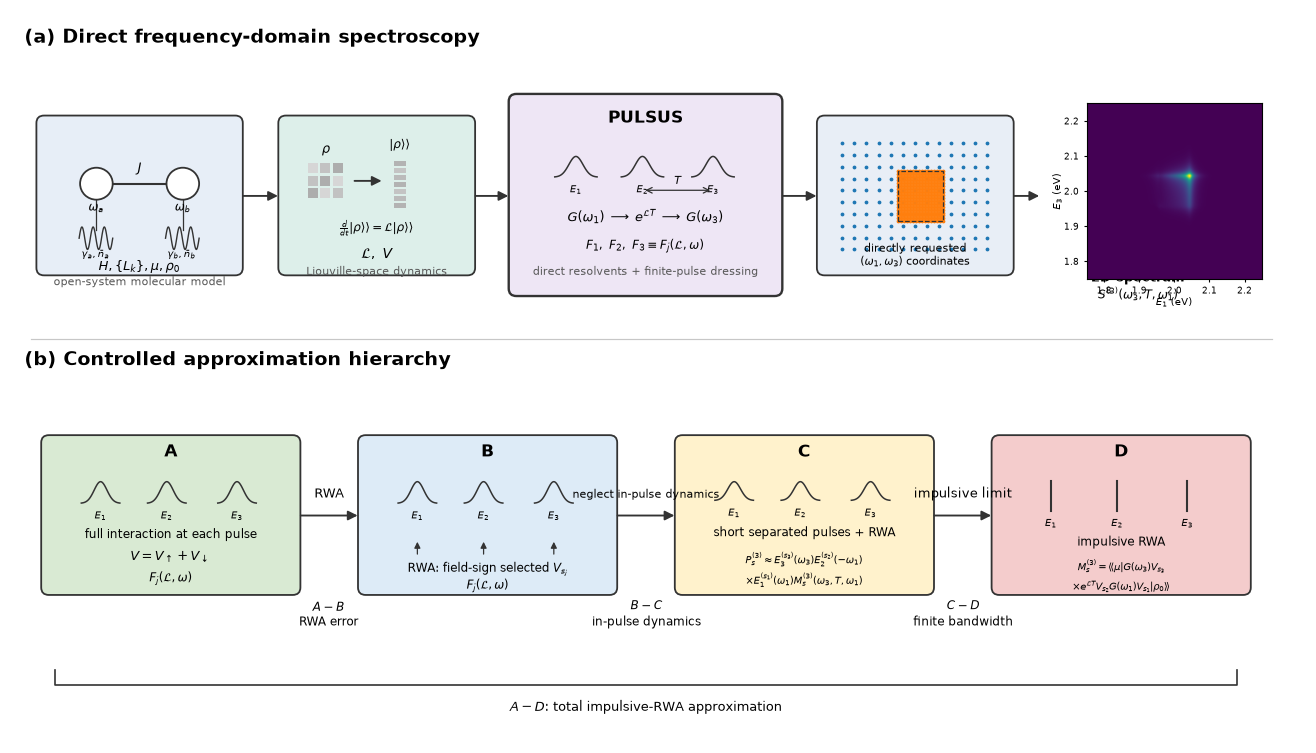

In [4]:
# ============================================================
# Figure 1 — Graphical PULSUS overview, revised
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Rectangle,
)


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(13.5, 7.8)
)

ax = fig.add_axes(
    [0.02, 0.03, 0.96, 0.94]
)

ax.set_xlim(0, 13.5)
ax.set_ylim(0, 7.8)
ax.axis("off")


# ============================================================
# Colors
# ============================================================

edge = "0.20"
muted = "0.35"

c_model = "#E7EEF7"
c_liouville = "#DDEFEA"
c_pulsus = "#EEE6F5"
c_sampling = "#E8EEF6"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"


# ============================================================
# Helper functions
# ============================================================

def rounded_box(
    x,
    y,
    w,
    h,
    facecolor,
    linewidth=1.3,
    radius=0.08,
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            f"round,pad=0.025,"
            f"rounding_size={radius}"
        ),
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=linewidth,
    )

    ax.add_patch(patch)

    return patch


def arrow(
    x1,
    y1,
    x2,
    y2,
    text=None,
    text_offset=0.16,
    fontsize=9,
):
    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.35,
        color=edge,
    )

    ax.add_patch(patch)

    if text is not None:
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + text_offset,
            text,
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def draw_bath(
    x0,
    y0,
    width=0.35,
    height=0.12,
):
    x = np.linspace(
        0,
        2 * np.pi,
        80,
    )

    xx = (
        x0
        + width
        * x
        / (2 * np.pi)
    )

    yy = (
        y0
        + height
        * np.sin(3 * x)
    )

    ax.plot(
        xx,
        yy,
        color=edge,
        linewidth=1.0,
    )


def draw_three_pulses(
    x0,
    y0,
    width,
    height,
    pulse_width=0.055,
):
    """
    Three separated Gaussian pulses.
    """

    centers = [
        0.15,
        0.48,
        0.83,
    ]

    x_local = np.linspace(
        -3,
        3,
        100,
    )

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
            + pulse_width
            * width
            * x_local
        )

        yy = (
            y0
            + height
            * np.exp(
                -0.5 * x_local**2
            )
        )

        ax.plot(
            xx,
            yy,
            color=edge,
            linewidth=1.1,
        )

        ax.text(
            x0 + center * width,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.5,
        )

    return centers


def draw_impulses(
    x0,
    y0,
    width,
    height,
):
    centers = [
        0.15,
        0.48,
        0.83,
    ]

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
        )

        ax.plot(
            [xx, xx],
            [
                y0,
                y0 + height,
            ],
            color=edge,
            linewidth=1.5,
        )

        ax.text(
            xx,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.5,
        )


# ============================================================
# PANEL (a)
# ============================================================

ax.text(
    0.15,
    7.45,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# 1. Open-system molecular model
# ============================================================

rounded_box(
    0.30,
    5.00,
    2.10,
    1.65,
    c_model,
)

site_y = 5.95

# Sites
ax.add_patch(
    Circle(
        (0.90, site_y),
        0.17,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.add_patch(
    Circle(
        (1.80, site_y),
        0.17,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

# Electronic coupling
ax.plot(
    [
        1.07,
        1.63,
    ],
    [
        site_y,
        site_y,
    ],
    color=edge,
    linewidth=1.5,
)

ax.text(
    1.35,
    site_y + 0.12,
    r"$J$",
    ha="center",
    fontsize=9,
)

ax.text(
    0.90,
    5.66,
    r"$\omega_a$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    1.80,
    5.66,
    r"$\omega_b$",
    ha="center",
    fontsize=8.5,
)


# ------------------------------------------------------------
# Independent thermal baths
# ------------------------------------------------------------

ax.plot(
    [
        0.90,
        0.90,
    ],
    [
        5.78,
        5.46,
    ],
    color=edge,
    linewidth=0.9,
)

ax.plot(
    [
        1.80,
        1.80,
    ],
    [
        5.78,
        5.46,
    ],
    color=edge,
    linewidth=0.9,
)

draw_bath(
    0.72,
    5.37,
)

draw_bath(
    1.62,
    5.37,
)

ax.text(
    0.89,
    5.17,
    r"$\gamma_a,\bar n_a$",
    ha="center",
    fontsize=7.5,
)

ax.text(
    1.79,
    5.17,
    r"$\gamma_b,\bar n_b$",
    ha="center",
    fontsize=7.5,
)

ax.text(
    1.35,
    5.03,
    r"$H,\{L_k\},\mu,\rho_0$",
    ha="center",
    fontsize=9.3,
)

ax.text(
    1.35,
    4.87,
    "open-system molecular model",
    ha="center",
    fontsize=8.0,
    color=muted,
)


arrow(
    2.40,
    5.82,
    2.82,
    5.82,
)


# ============================================================
# 2. Liouville-space transformation
# ============================================================

rounded_box(
    2.82,
    5.00,
    2.00,
    1.65,
    c_liouville,
)


# Density matrix graphic
rho_x = 3.10
rho_y = 5.80

for i in range(3):

    for j in range(3):

        value = (
            0.68
            + 0.08
            * ((i + 2 * j) % 3)
        )

        ax.add_patch(
            Rectangle(
                (
                    rho_x + 0.13 * j,
                    rho_y + 0.13 * i,
                ),
                0.105,
                0.105,
                facecolor=str(value),
                edgecolor="none",
            )
        )

ax.text(
    3.29,
    6.28,
    r"$\rho$",
    ha="center",
    fontsize=9,
)


# vectorization arrow
arrow(
    3.56,
    5.98,
    3.90,
    5.98,
)


# vectorized rho
for i in range(7):

    ax.add_patch(
        Rectangle(
            (
                4.00,
                5.69 + 0.075 * i,
            ),
            0.12,
            0.055,
            facecolor=str(
                0.70
                + 0.035 * (i % 3)
            ),
            edgecolor="none",
        )
    )

ax.text(
    4.06,
    6.32,
    r"$|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    3.82,
    5.44,
    r"$\frac{d}{dt}|\rho\rangle\rangle"
    r"=\mathcal{L}|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    3.82,
    5.15,
    r"$\mathcal{L},\ V$",
    ha="center",
    fontsize=10,
)

ax.text(
    3.82,
    4.98,
    "Liouville-space dynamics",
    ha="center",
    fontsize=8,
    color=muted,
)


arrow(
    4.82,
    5.82,
    5.22,
    5.82,
)


# ============================================================
# 3. PULSUS engine
# ============================================================

rounded_box(
    5.22,
    4.78,
    2.80,
    2.10,
    c_pulsus,
    linewidth=1.7,
)

ax.text(
    6.62,
    6.60,
    "PULSUS",
    ha="center",
    fontsize=12.5,
    weight="bold",
)


# ------------------------------------------------------------
# Three finite pulses
# ------------------------------------------------------------

pulse_x0 = 5.58
pulse_y0 = 6.02
pulse_width = 2.10

pulse_centers = draw_three_pulses(
    pulse_x0,
    pulse_y0,
    pulse_width,
    0.22,
    pulse_width=0.035,
)

# Waiting time T between pulse 2 and pulse 3
x2 = (
    pulse_x0
    + pulse_centers[1] * pulse_width
)

x3 = (
    pulse_x0
    + pulse_centers[2] * pulse_width
)

ax.annotate(
    "",
    xy=(x3, 5.88),
    xytext=(x2, 5.88),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=0.9,
        color=edge,
    ),
)

ax.text(
    (x2 + x3) / 2,
    5.91,
    r"$T$",
    ha="center",
    va="bottom",
    fontsize=8,
)


# ------------------------------------------------------------
# Frequency-domain machinery
# ------------------------------------------------------------

ax.text(
    6.62,
    5.55,
    r"$G(\omega_1)$"
    r"$\;\longrightarrow\;$"
    r"$e^{\mathcal{L}T}$"
    r"$\;\longrightarrow\;$"
    r"$G(\omega_3)$",
    ha="center",
    fontsize=9.3,
)

ax.text(
    6.62,
    5.25,
    r"$F_1,\ F_2,\ F_3"
    r"\equiv F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.8,
)

ax.text(
    6.62,
    4.98,
    "direct resolvents + finite-pulse dressing",
    ha="center",
    fontsize=7.9,
    color=muted,
)


arrow(
    8.02,
    5.82,
    8.43,
    5.82,
)


# ============================================================
# 4. Requested spectral coordinates
# ============================================================

rounded_box(
    8.43,
    5.00,
    2.00,
    1.65,
    c_sampling,
)


# ------------------------------------------------------------
# Coarse survey + dense target patch
# ------------------------------------------------------------

x_min = 8.67
x_max = 10.18

y_min = 5.25
y_max = 6.38

# coarse background
x_coarse = np.linspace(
    x_min,
    x_max,
    13,
)

y_coarse = np.linspace(
    y_min,
    y_max,
    10,
)

Xc, Yc = np.meshgrid(
    x_coarse,
    y_coarse,
)

ax.scatter(
    Xc.ravel(),
    Yc.ravel(),
    s=3.0,
)

# dense selected region
x_dense = np.linspace(
    9.25,
    9.72,
    16,
)

y_dense = np.linspace(
    5.55,
    6.08,
    18,
)

Xd, Yd = np.meshgrid(
    x_dense,
    y_dense,
)

ax.scatter(
    Xd.ravel(),
    Yd.ravel(),
    s=3.0,
)

ax.add_patch(
    Rectangle(
        (
            9.25,
            5.55,
        ),
        0.47,
        0.53,
        fill=False,
        linestyle="--",
        linewidth=0.9,
        edgecolor=edge,
    )
)

ax.text(
    9.43,
    5.08,
    "directly requested"
    "\n"
    r"$(\omega_1,\omega_3)$ coordinates",
    ha="center",
    fontsize=7.8,
)


arrow(
    10.43,
    5.82,
    10.75,
    5.82,
)


# ============================================================
# 5. Actual PULSUS 2D spectrum
# ============================================================

ax_spec = fig.add_axes(
    [
        0.805,
        0.625,
        0.155,
        0.225,
    ]
)

ax_spec.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax_spec.set_xlabel(
    r"$E_1$ (eV)",
    fontsize=7.5,
    labelpad=1,
)

ax_spec.set_ylabel(
    r"$E_3$ (eV)",
    fontsize=7.5,
    labelpad=1,
)

ax_spec.tick_params(
    labelsize=6.5,
    length=2,
)

ax.text(
    11.75,
    4.91,
    "2D spectrum",
    ha="center",
    fontsize=9,
    weight="bold",
)

ax.text(
    11.75,
    4.72,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=8.5,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [
        0.22,
        13.15,
    ],
    [
        4.30,
        4.30,
    ],
    linewidth=0.85,
    color="0.78",
)


# ============================================================
# PANEL (b)
# ============================================================

ax.text(
    0.15,
    4.02,
    "(b) Controlled approximation hierarchy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# Model geometry
# ============================================================

box_y = 1.60
box_h = 1.65
box_w = 2.65

xA = 0.35
xB = 3.65
xC = 6.95
xD = 10.25


# ============================================================
# A — full finite-pulse interaction
# ============================================================

rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    c_A,
)

ax.text(
    xA + box_w / 2,
    3.04,
    r"$\mathbf{A}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xA + 0.28,
    2.55,
    box_w - 0.56,
    0.23,
    pulse_width=0.032,
)

ax.text(
    xA + box_w / 2,
    2.18,
    r"full interaction at each pulse",
    ha="center",
    fontsize=8.5,
)

ax.text(
    xA + box_w / 2,
    1.94,
    r"$V=V_{\uparrow}+V_{\downarrow}$",
    ha="center",
    fontsize=9.2,
)

ax.text(
    xA + box_w / 2,
    1.72,
    r"$F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.5,
)


# ============================================================
# B — RWA
# ============================================================

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    c_B,
)

ax.text(
    xB + box_w / 2,
    3.04,
    r"$\mathbf{B}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

centers_B = draw_three_pulses(
    xB + 0.28,
    2.55,
    box_w - 0.56,
    0.23,
    pulse_width=0.032,
)

# graphical selected interaction beneath pulses
for center in centers_B:

    xx = (
        xB
        + 0.28
        + center
        * (box_w - 0.56)
    )

    ax.annotate(
        "",
        xy=(xx, 2.17),
        xytext=(xx, 1.98),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=9,
            linewidth=0.9,
            color=edge,
        ),
    )

ax.text(
    xB + box_w / 2,
    1.82,
    r"RWA: field-sign selected $V_{s_j}$",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xB + box_w / 2,
    1.64,
    r"$F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.3,
)


# ============================================================
# C — scalar short-pulse factorization
# ============================================================

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    c_C,
)

ax.text(
    xC + box_w / 2,
    3.04,
    r"$\mathbf{C}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xC + 0.28,
    2.58,
    box_w - 0.56,
    0.20,
    pulse_width=0.032,
)

ax.text(
    xC + box_w / 2,
    2.20,
    "short separated pulses + RWA",
    ha="center",
    fontsize=8.3,
)

ax.text(
    xC + box_w / 2,
    1.91,
    r"$P_s^{(3)}"
    r"\approx E_3^{(s_3)}(\omega_3)"
    r"E_2^{(s_2)}(-\omega_1)$",
    ha="center",
    fontsize=7.1,
)

ax.text(
    xC + box_w / 2,
    1.69,
    r"$\times E_1^{(s_1)}(\omega_1)"
    r"M_s^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=7.1,
)


# ============================================================
# D — impulsive RWA
# ============================================================

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    c_D,
)

ax.text(
    xD + box_w / 2,
    3.04,
    r"$\mathbf{D}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_impulses(
    xD + 0.28,
    2.47,
    box_w - 0.56,
    0.32,
)

ax.text(
    xD + box_w / 2,
    2.10,
    "impulsive RWA",
    ha="center",
    fontsize=8.5,
)

ax.text(
    xD + box_w / 2,
    1.83,
    r"$M_s^{(3)}="
    r"\langle\!\langle\mu|G(\omega_3)V_{s_3}$",
    ha="center",
    fontsize=6.9,
)

ax.text(
    xD + box_w / 2,
    1.63,
    r"$\times e^{\mathcal{L}T}"
    r"V_{s_2}G(\omega_1)V_{s_1}"
    r"|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.9,
)


# ============================================================
# Approximation arrows
# ============================================================

arrow(
    xA + box_w,
    2.42,
    xB,
    2.42,
    text="RWA",
    text_offset=0.16,
)

arrow(
    xB + box_w,
    2.42,
    xC,
    2.42,
    text="neglect in-pulse dynamics",
    text_offset=0.16,
    fontsize=8.2,
)

arrow(
    xC + box_w,
    2.42,
    xD,
    2.42,
    text="impulsive limit",
    text_offset=0.16,
)


# ============================================================
# What each model difference isolates
# ============================================================

ax.text(
    3.32,
    1.25,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    fontsize=8.8,
)

ax.text(
    6.63,
    1.25,
    r"$B-C$"
    "\n"
    "in-pulse dynamics",
    ha="center",
    fontsize=8.8,
)

ax.text(
    9.93,
    1.25,
    r"$C-D$"
    "\n"
    "finite bandwidth",
    ha="center",
    fontsize=8.8,
)


# ============================================================
# Total A-D bracket
# ============================================================

y_bracket = 0.62

ax.plot(
    [
        xA + 0.12,
        xA + 0.12,
        xD + box_w - 0.12,
        xD + box_w - 0.12,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    0.34,
    r"$A-D$: total impulsive-RWA approximation",
    ha="center",
    fontsize=9.3,
)


plt.show()

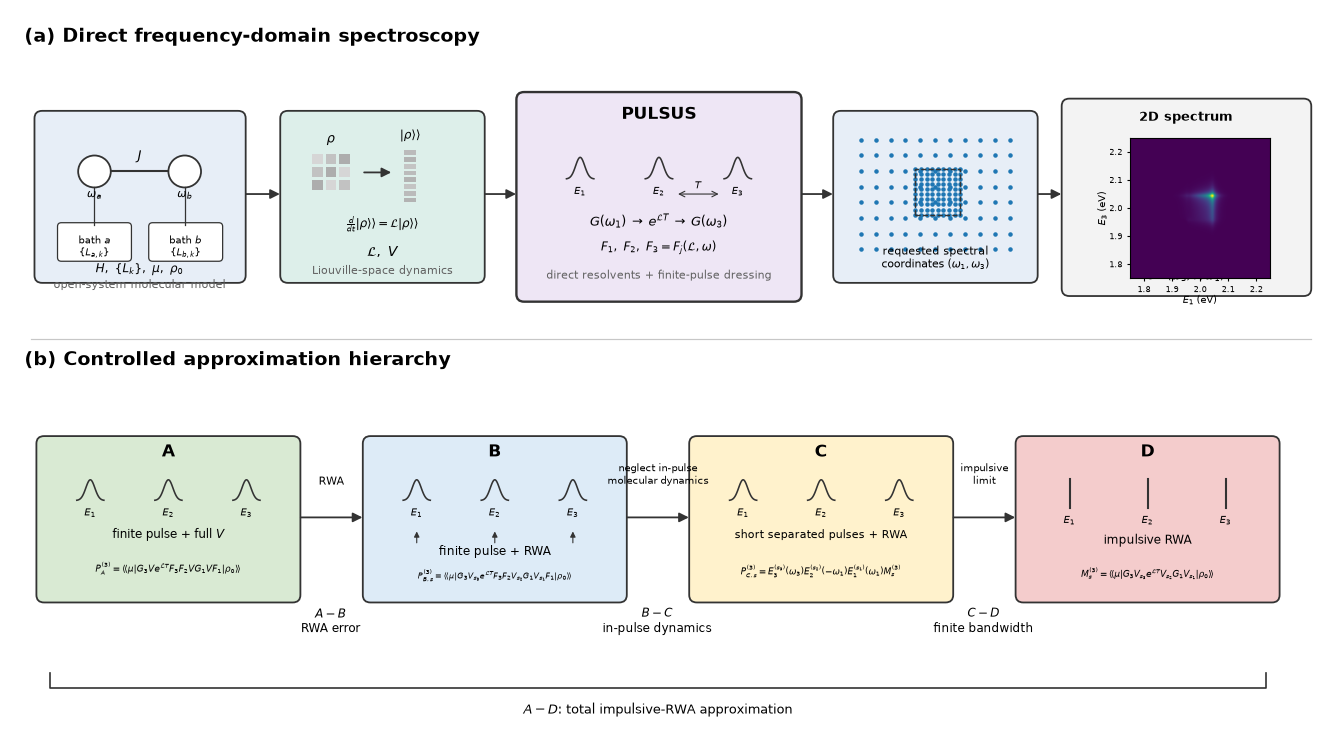

In [5]:
# ============================================================
# Figure 1 — Graphical PULSUS overview, revised draft
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Rectangle,
)


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(13.8, 7.8)
)

ax = fig.add_axes(
    [0.02, 0.03, 0.96, 0.94]
)

ax.set_xlim(0, 13.8)
ax.set_ylim(0, 7.8)
ax.axis("off")


# ============================================================
# Colors
# ============================================================

edge = "0.20"
muted = "0.38"

c_model = "#E7EEF7"
c_liouville = "#DDEFEA"
c_pulsus = "#EEE6F5"
c_sampling = "#E7EEF7"
c_spectrum = "#F3F3F3"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"

sampling_blue = "C0"


# ============================================================
# Helpers
# ============================================================

def rounded_box(
    x,
    y,
    w,
    h,
    facecolor,
    linewidth=1.3,
    radius=0.08,
):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            f"round,pad=0.025,"
            f"rounding_size={radius}"
        ),
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=linewidth,
    )

    ax.add_patch(
        patch
    )

    return patch


def arrow(
    x1,
    y1,
    x2,
    y2,
    text=None,
    text_offset=0.14,
    fontsize=8.5,
):

    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.3,
        color=edge,
    )

    ax.add_patch(
        patch
    )

    if text is not None:

        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + text_offset,
            text,
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def draw_three_pulses(
    x0,
    y0,
    width,
    height,
    pulse_width=0.025,
    label=True,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    x_local = np.linspace(
        -3,
        3,
        120,
    )

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
            + pulse_width
            * width
            * x_local
        )

        yy = (
            y0
            + height
            * np.exp(
                -0.5 * x_local**2
            )
        )

        ax.plot(
            xx,
            yy,
            color=edge,
            linewidth=1.15,
        )

        if label:

            ax.text(
                x0 + center * width,
                y0 - 0.08,
                rf"$E_{i+1}$",
                ha="center",
                va="top",
                fontsize=7.3,
            )

    return centers


def draw_impulses(
    x0,
    y0,
    width,
    height,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
        )

        ax.plot(
            [xx, xx],
            [
                y0,
                y0 + height,
            ],
            color=edge,
            linewidth=1.5,
        )

        ax.text(
            xx,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )


# ============================================================
# PANEL (a)
# ============================================================

ax.text(
    0.15,
    7.46,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# 1. Open-system molecular model
# ============================================================

rounded_box(
    0.28,
    4.92,
    2.15,
    1.78,
    c_model,
)

site_y = 6.08

# Sites
ax.add_patch(
    Circle(
        (0.88, site_y),
        0.17,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.add_patch(
    Circle(
        (1.82, site_y),
        0.17,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

# Coupling
ax.plot(
    [
        1.05,
        1.65,
    ],
    [
        site_y,
        site_y,
    ],
    color=edge,
    linewidth=1.5,
)

ax.text(
    1.35,
    6.20,
    r"$J$",
    ha="center",
    fontsize=9,
)

ax.text(
    0.88,
    5.80,
    r"$\omega_a$",
    ha="center",
    fontsize=8.2,
)

ax.text(
    1.82,
    5.80,
    r"$\omega_b$",
    ha="center",
    fontsize=8.2,
)


# ------------------------------------------------------------
# Thermal bath boxes
# ------------------------------------------------------------

bath_w = 0.72
bath_h = 0.36

rounded_box(
    0.52,
    5.15,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

rounded_box(
    1.47,
    5.15,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

ax.plot(
    [
        0.88,
        0.88,
    ],
    [
        5.91,
        5.51,
    ],
    color=edge,
    linewidth=0.9,
)

ax.plot(
    [
        1.82,
        1.82,
    ],
    [
        5.91,
        5.51,
    ],
    color=edge,
    linewidth=0.9,
)

ax.text(
    0.88,
    5.34,
    "bath $a$",
    ha="center",
    va="center",
    fontsize=7.2,
)

ax.text(
    0.88,
    5.21,
    r"$\{L_{a,k}\}$",
    ha="center",
    va="center",
    fontsize=7.2,
)

ax.text(
    1.83,
    5.34,
    "bath $b$",
    ha="center",
    va="center",
    fontsize=7.2,
)

ax.text(
    1.83,
    5.21,
    r"$\{L_{b,k}\}$",
    ha="center",
    va="center",
    fontsize=7.2,
)


ax.text(
    1.35,
    5.00,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$",
    ha="center",
    fontsize=8.7,
)

ax.text(
    1.35,
    4.84,
    "open-system molecular model",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    2.43,
    5.84,
    2.84,
    5.84,
)


# ============================================================
# 2. Liouville-space representation
# ============================================================

rounded_box(
    2.84,
    4.92,
    2.08,
    1.78,
    c_liouville,
)


# ------------------------------------------------------------
# rho matrix
# ------------------------------------------------------------

rho_x = 3.15
rho_y = 5.88

for i in range(3):

    for j in range(3):

        shade = (
            0.68
            + 0.08
            * ((i + 2 * j) % 3)
        )

        ax.add_patch(
            Rectangle(
                (
                    rho_x + 0.14 * j,
                    rho_y + 0.14 * i,
                ),
                0.11,
                0.11,
                facecolor=str(shade),
                edgecolor="none",
            )
        )

ax.text(
    3.34,
    6.39,
    r"$\rho$",
    ha="center",
    fontsize=9,
)


# ------------------------------------------------------------
# vectorization arrow
# ------------------------------------------------------------

arrow(
    3.66,
    6.07,
    4.00,
    6.07,
)


# ------------------------------------------------------------
# |rho>>
# ------------------------------------------------------------

for i in range(8):

    ax.add_patch(
        Rectangle(
            (
                4.10,
                5.75 + 0.072 * i,
            ),
            0.13,
            0.052,
            facecolor=str(
                0.70
                + 0.035 * (i % 3)
            ),
            edgecolor="none",
        )
    )

ax.text(
    4.17,
    6.42,
    r"$|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    3.88,
    5.48,
    r"$\frac{d}{dt}|\rho\rangle\rangle"
    r"=\mathcal{L}|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.3,
)

ax.text(
    3.88,
    5.18,
    r"$\mathcal{L},\ V$",
    ha="center",
    fontsize=9.8,
)

ax.text(
    3.88,
    4.99,
    "Liouville-space dynamics",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    4.92,
    5.84,
    5.30,
    5.84,
)


# ============================================================
# 3. PULSUS
# ============================================================

rounded_box(
    5.30,
    4.72,
    2.92,
    2.18,
    c_pulsus,
    linewidth=1.7,
)

ax.text(
    6.76,
    6.64,
    "PULSUS",
    ha="center",
    fontsize=12.5,
    weight="bold",
)


# ------------------------------------------------------------
# Pulse sequence
# ------------------------------------------------------------

pulse_x0 = 5.68
pulse_y0 = 6.00
pulse_width = 2.16

pulse_centers = draw_three_pulses(
    pulse_x0,
    pulse_y0,
    pulse_width,
    0.23,
    pulse_width=0.022,
)


# ------------------------------------------------------------
# Smaller T marker between E2 and E3
# ------------------------------------------------------------

x2 = (
    pulse_x0
    + pulse_centers[1] * pulse_width
)

x3 = (
    pulse_x0
    + pulse_centers[2] * pulse_width
)

T_left = (
    x2
    + 0.17
)

T_right = (
    x3
    - 0.17
)

ax.annotate(
    "",
    xy=(T_right, 5.84),
    xytext=(T_left, 5.84),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=0.8,
        color=edge,
    ),
)

ax.text(
    (T_left + T_right) / 2,
    5.87,
    r"$T$",
    ha="center",
    va="bottom",
    fontsize=7.5,
)


# ------------------------------------------------------------
# PULSUS equations
# ------------------------------------------------------------

ax.text(
    6.76,
    5.50,
    r"$G(\omega_1)"
    r"\;\rightarrow\;"
    r"e^{\mathcal{L}T}"
    r"\;\rightarrow\;"
    r"G(\omega_3)$",
    ha="center",
    fontsize=9.1,
)

ax.text(
    6.76,
    5.23,
    r"$F_1,\ F_2,\ F_3"
    r"=F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.6,
)

ax.text(
    6.76,
    4.94,
    "direct resolvents + finite-pulse dressing",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    8.22,
    5.84,
    8.60,
    5.84,
)


# ============================================================
# 4. Requested spectral coordinates
# ============================================================

rounded_box(
    8.60,
    4.92,
    2.08,
    1.78,
    c_sampling,
)


# ------------------------------------------------------------
# Coarse background
# ------------------------------------------------------------

x_min = 8.86
x_max = 10.42

y_min = 5.25
y_max = 6.42

x_coarse = np.linspace(
    x_min,
    x_max,
    11,
)

y_coarse = np.linspace(
    y_min,
    y_max,
    8,
)

Xc, Yc = np.meshgrid(
    x_coarse,
    y_coarse,
)

ax.scatter(
    Xc.ravel(),
    Yc.ravel(),
    s=5.0,
    color=sampling_blue,
)


# ------------------------------------------------------------
# Moderately denser selected region
# ------------------------------------------------------------

x_dense = np.linspace(
    9.43,
    9.90,
    9,
)

y_dense = np.linspace(
    5.62,
    6.11,
    10,
)

Xd, Yd = np.meshgrid(
    x_dense,
    y_dense,
)

ax.scatter(
    Xd.ravel(),
    Yd.ravel(),
    s=5.0,
    color=sampling_blue,
)

ax.add_patch(
    Rectangle(
        (
            9.43,
            5.62,
        ),
        0.47,
        0.49,
        fill=False,
        linestyle="--",
        linewidth=1.0,
        edgecolor=edge,
    )
)

ax.text(
    9.64,
    5.05,
    "requested spectral"
    "\n"
    r"coordinates $(\omega_1,\omega_3)$",
    ha="center",
    fontsize=7.7,
)


arrow(
    10.68,
    5.84,
    10.98,
    5.84,
)


# ============================================================
# 5. Actual spectrum in a box
# ============================================================

rounded_box(
    10.98,
    4.78,
    2.55,
    2.05,
    c_spectrum,
)

ax.text(
    12.25,
    6.62,
    "2D spectrum",
    ha="center",
    fontsize=9.5,
    weight="bold",
)

# Actual spectrum inset
ax_spec = fig.add_axes(
    [
        0.815,
        0.626,
        0.135,
        0.180,
    ]
)

ax_spec.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax_spec.set_xlabel(
    r"$E_1$ (eV)",
    fontsize=7.0,
    labelpad=1,
)

ax_spec.set_ylabel(
    r"$E_3$ (eV)",
    fontsize=7.0,
    labelpad=1,
)

ax_spec.tick_params(
    labelsize=6.0,
    length=2,
)

ax.text(
    12.25,
    4.93,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=8.2,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [
        0.22,
        13.55,
    ],
    [
        4.30,
        4.30,
    ],
    linewidth=0.85,
    color="0.78",
)


# ============================================================
# PANEL (b)
# ============================================================

ax.text(
    0.15,
    4.02,
    "(b) Controlled approximation hierarchy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# Model boxes
# ============================================================

box_y = 1.52
box_h = 1.72
box_w = 2.70

xA = 0.30
xB = 3.70
xC = 7.10
xD = 10.50


# ============================================================
# A
# ============================================================

rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    c_A,
)

ax.text(
    xA + box_w / 2,
    3.04,
    r"$\mathbf{A}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xA + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
    pulse_width=0.022,
)

ax.text(
    xA + box_w / 2,
    2.18,
    r"finite pulse + full $V$",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xA + box_w / 2,
    1.82,
    r"$P_A^{(3)}="
    r"\langle\!\langle\mu|G_3Ve^{\mathcal{L}T}"
    r"F_3F_2VG_1VF_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.6,
)


# ============================================================
# B
# ============================================================

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    c_B,
)

ax.text(
    xB + box_w / 2,
    3.04,
    r"$\mathbf{B}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

centers_B = draw_three_pulses(
    xB + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
    pulse_width=0.022,
)

# RWA-selected interaction arrows
for center in centers_B:

    xx = (
        xB
        + 0.28
        + center
        * (box_w - 0.56)
    )

    ax.annotate(
        "",
        xy=(xx, 2.28),
        xytext=(xx, 2.10),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.8,
            color=edge,
        ),
    )

ax.text(
    xB + box_w / 2,
    2.00,
    r"finite pulse + RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xB + box_w / 2,
    1.75,
    r"$P_{B,s}^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"F_3F_2V_{s_2}G_1V_{s_1}F_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.1,
)


# ============================================================
# C
# ============================================================

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    c_C,
)

ax.text(
    xC + box_w / 2,
    3.04,
    r"$\mathbf{C}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xC + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
    pulse_width=0.022,
)

ax.text(
    xC + box_w / 2,
    2.18,
    "short separated pulses + RWA",
    ha="center",
    fontsize=8.1,
)

ax.text(
    xC + box_w / 2,
    1.79,
    r"$P_{C,s}^{(3)}="
    r"E_3^{(s_3)}(\omega_3)"
    r"E_2^{(s_2)}(-\omega_1)"
    r"E_1^{(s_1)}(\omega_1)"
    r"M_s^{(3)}$",
    ha="center",
    fontsize=6.4,
)


# ============================================================
# D
# ============================================================

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    c_D,
)

ax.text(
    xD + box_w / 2,
    3.04,
    r"$\mathbf{D}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_impulses(
    xD + 0.28,
    2.50,
    box_w - 0.56,
    0.31,
)

ax.text(
    xD + box_w / 2,
    2.12,
    "impulsive RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xD + box_w / 2,
    1.76,
    r"$M_s^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"V_{s_2}G_1V_{s_1}|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.3,
)


# ============================================================
# Approximation arrows
# ============================================================

arrow(
    xA + box_w,
    2.40,
    xB,
    2.40,
)

arrow(
    xB + box_w,
    2.40,
    xC,
    2.40,
)

arrow(
    xC + box_w,
    2.40,
    xD,
    2.40,
)


# ------------------------------------------------------------
# Put approximation labels ABOVE the gaps
# ------------------------------------------------------------

ax.text(
    (
        xA + box_w + xB
    ) / 2,
    2.72,
    "RWA",
    ha="center",
    va="bottom",
    fontsize=8.2,
)

ax.text(
    (
        xB + box_w + xC
    ) / 2,
    2.72,
    "neglect in-pulse"
    "\n"
    "molecular dynamics",
    ha="center",
    va="bottom",
    fontsize=7.5,
)

ax.text(
    (
        xC + box_w + xD
    ) / 2,
    2.72,
    "impulsive"
    "\n"
    "limit",
    ha="center",
    va="bottom",
    fontsize=7.5,
)


# ============================================================
# Error channels
# ============================================================

ax.text(
    3.34,
    1.18,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    fontsize=8.5,
)

ax.text(
    6.74,
    1.18,
    r"$B-C$"
    "\n"
    "in-pulse dynamics",
    ha="center",
    fontsize=8.5,
)

ax.text(
    10.14,
    1.18,
    r"$C-D$"
    "\n"
    "finite bandwidth",
    ha="center",
    fontsize=8.5,
)


# ============================================================
# Total A-D bracket
# ============================================================

y_bracket = 0.58

ax.plot(
    [
        xA + 0.12,
        xA + 0.12,
        xD + box_w - 0.12,
        xD + box_w - 0.12,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    0.31,
    r"$A-D$: total impulsive-RWA approximation",
    ha="center",
    fontsize=9.2,
)


plt.show()

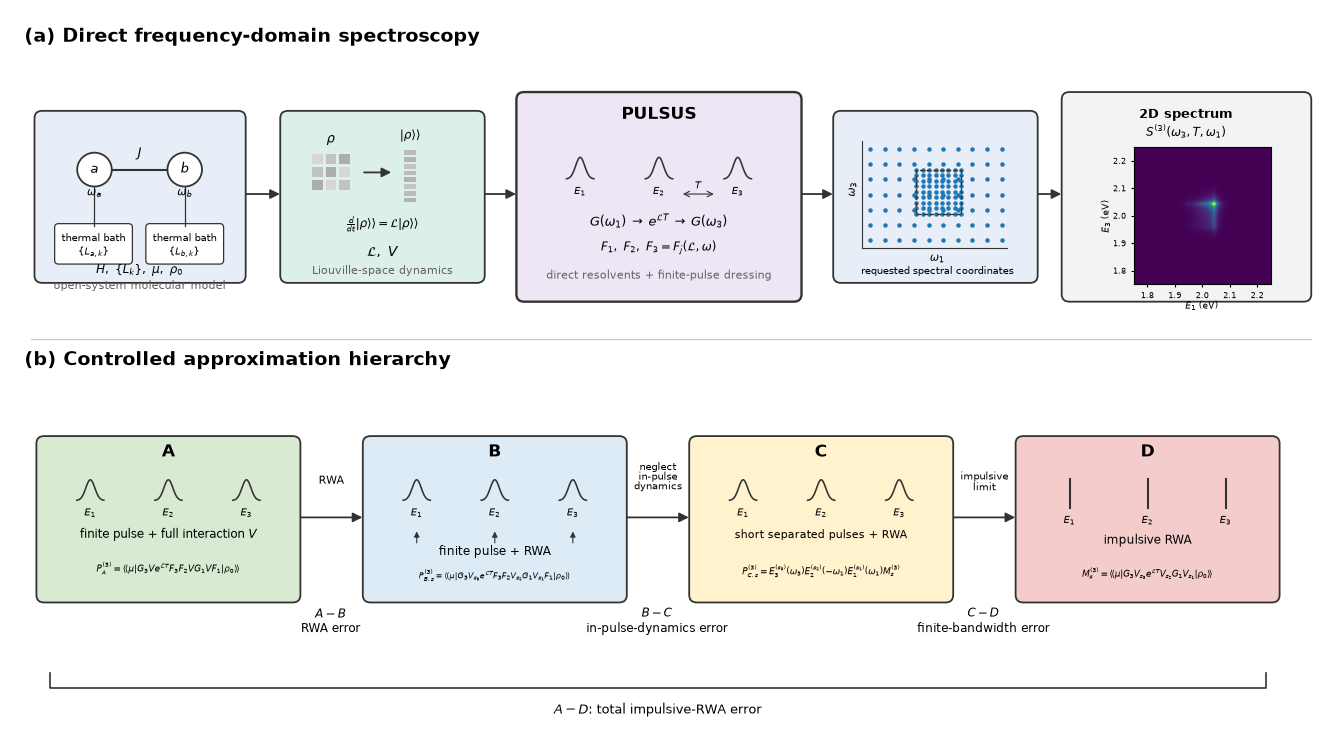

In [6]:
# ============================================================
# Figure 1 — Graphical PULSUS overview
# Revised labeling and layout
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Rectangle,
)


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(13.8, 7.8)
)

ax = fig.add_axes(
    [0.02, 0.03, 0.96, 0.94]
)

ax.set_xlim(0, 13.8)
ax.set_ylim(0, 7.8)
ax.axis("off")


# ============================================================
# Colors
# ============================================================

edge = "0.20"
muted = "0.38"

c_model = "#E7EEF7"
c_liouville = "#DDEFEA"
c_pulsus = "#EEE6F5"
c_sampling = "#E7EEF7"
c_spectrum = "#F3F3F3"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"

sampling_blue = "C0"


# ============================================================
# Helpers
# ============================================================

def rounded_box(
    x,
    y,
    w,
    h,
    facecolor,
    linewidth=1.3,
    radius=0.08,
):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            f"round,pad=0.025,"
            f"rounding_size={radius}"
        ),
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=linewidth,
    )

    ax.add_patch(patch)

    return patch


def arrow(
    x1,
    y1,
    x2,
    y2,
):

    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.3,
        color=edge,
    )

    ax.add_patch(patch)


def draw_three_pulses(
    x0,
    y0,
    width,
    height,
    pulse_width=0.022,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    x_local = np.linspace(
        -3,
        3,
        120,
    )

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
            + pulse_width
            * width
            * x_local
        )

        yy = (
            y0
            + height
            * np.exp(
                -0.5 * x_local**2
            )
        )

        ax.plot(
            xx,
            yy,
            color=edge,
            linewidth=1.15,
        )

        ax.text(
            x0 + center * width,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )

    return centers


def draw_impulses(
    x0,
    y0,
    width,
    height,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
        )

        ax.plot(
            [xx, xx],
            [
                y0,
                y0 + height,
            ],
            color=edge,
            linewidth=1.5,
        )

        ax.text(
            xx,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )


# ============================================================
# PANEL (a)
# ============================================================

ax.text(
    0.15,
    7.46,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# 1. Open-system molecular model
# ============================================================

rounded_box(
    0.28,
    4.92,
    2.15,
    1.78,
    c_model,
)

site_y = 6.10


# ------------------------------------------------------------
# Subsystems a and b
# ------------------------------------------------------------

ax.add_patch(
    Circle(
        (0.88, site_y),
        0.18,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.add_patch(
    Circle(
        (1.82, site_y),
        0.18,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.text(
    0.88,
    site_y,
    r"$a$",
    ha="center",
    va="center",
    fontsize=9,
)

ax.text(
    1.82,
    site_y,
    r"$b$",
    ha="center",
    va="center",
    fontsize=9,
)


# ------------------------------------------------------------
# Coupling J
# ------------------------------------------------------------

ax.plot(
    [
        1.06,
        1.64,
    ],
    [
        site_y,
        site_y,
    ],
    color=edge,
    linewidth=1.5,
)

ax.text(
    1.35,
    6.23,
    r"$J$",
    ha="center",
    fontsize=9,
)

ax.text(
    0.88,
    5.82,
    r"$\omega_a$",
    ha="center",
    fontsize=8.2,
)

ax.text(
    1.82,
    5.82,
    r"$\omega_b$",
    ha="center",
    fontsize=8.2,
)


# ------------------------------------------------------------
# Independent thermal baths
# ------------------------------------------------------------

bath_w = 0.76
bath_h = 0.38

rounded_box(
    0.49,
    5.12,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

rounded_box(
    1.44,
    5.12,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

ax.plot(
    [
        0.88,
        0.88,
    ],
    [
        5.92,
        5.50,
    ],
    color=edge,
    linewidth=0.9,
)

ax.plot(
    [
        1.82,
        1.82,
    ],
    [
        5.92,
        5.50,
    ],
    color=edge,
    linewidth=0.9,
)

ax.text(
    0.87,
    5.37,
    "thermal bath",
    ha="center",
    va="center",
    fontsize=6.9,
)

ax.text(
    0.87,
    5.22,
    r"$\{L_{a,k}\}$",
    ha="center",
    va="center",
    fontsize=7.3,
)

ax.text(
    1.82,
    5.37,
    "thermal bath",
    ha="center",
    va="center",
    fontsize=6.9,
)

ax.text(
    1.82,
    5.22,
    r"$\{L_{b,k}\}$",
    ha="center",
    va="center",
    fontsize=7.3,
)


ax.text(
    1.35,
    4.99,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$",
    ha="center",
    fontsize=8.6,
)

ax.text(
    1.35,
    4.83,
    "open-system molecular model",
    ha="center",
    fontsize=7.7,
    color=muted,
)


arrow(
    2.43,
    5.84,
    2.84,
    5.84,
)


# ============================================================
# 2. Liouville-space representation
# ============================================================

rounded_box(
    2.84,
    4.92,
    2.08,
    1.78,
    c_liouville,
)


# ------------------------------------------------------------
# rho matrix
# ------------------------------------------------------------

rho_x = 3.15
rho_y = 5.88

for i in range(3):

    for j in range(3):

        shade = (
            0.68
            + 0.08
            * ((i + 2 * j) % 3)
        )

        ax.add_patch(
            Rectangle(
                (
                    rho_x + 0.14 * j,
                    rho_y + 0.14 * i,
                ),
                0.11,
                0.11,
                facecolor=str(shade),
                edgecolor="none",
            )
        )

ax.text(
    3.34,
    6.39,
    r"$\rho$",
    ha="center",
    fontsize=9,
)


# ------------------------------------------------------------
# Vectorization
# ------------------------------------------------------------

arrow(
    3.66,
    6.07,
    4.00,
    6.07,
)


for i in range(8):

    ax.add_patch(
        Rectangle(
            (
                4.10,
                5.75 + 0.072 * i,
            ),
            0.13,
            0.052,
            facecolor=str(
                0.70
                + 0.035 * (i % 3)
            ),
            edgecolor="none",
        )
    )

ax.text(
    4.17,
    6.42,
    r"$|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    3.88,
    5.48,
    r"$\frac{d}{dt}|\rho\rangle\rangle"
    r"=\mathcal{L}|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.3,
)

ax.text(
    3.88,
    5.18,
    r"$\mathcal{L},\ V$",
    ha="center",
    fontsize=9.8,
)

ax.text(
    3.88,
    4.99,
    "Liouville-space dynamics",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    4.92,
    5.84,
    5.30,
    5.84,
)


# ============================================================
# 3. PULSUS
# ============================================================

rounded_box(
    5.30,
    4.72,
    2.92,
    2.18,
    c_pulsus,
    linewidth=1.7,
)

ax.text(
    6.76,
    6.64,
    "PULSUS",
    ha="center",
    fontsize=12.5,
    weight="bold",
)


# ------------------------------------------------------------
# Three finite pulses
# ------------------------------------------------------------

pulse_x0 = 5.68
pulse_y0 = 6.00
pulse_width = 2.16

pulse_centers = draw_three_pulses(
    pulse_x0,
    pulse_y0,
    pulse_width,
    0.23,
)


# ------------------------------------------------------------
# Waiting time T between pulse 2 and pulse 3
# ------------------------------------------------------------

x2 = (
    pulse_x0
    + pulse_centers[1] * pulse_width
)

x3 = (
    pulse_x0
    + pulse_centers[2] * pulse_width
)

T_left = x2 + 0.22
T_right = x3 - 0.22

ax.annotate(
    "",
    xy=(T_right, 5.84),
    xytext=(T_left, 5.84),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=0.8,
        color=edge,
    ),
)

ax.text(
    (T_left + T_right) / 2,
    5.87,
    r"$T$",
    ha="center",
    va="bottom",
    fontsize=7.5,
)


# ------------------------------------------------------------
# Frequency-domain machinery
# ------------------------------------------------------------

ax.text(
    6.76,
    5.50,
    r"$G(\omega_1)"
    r"\;\rightarrow\;"
    r"e^{\mathcal{L}T}"
    r"\;\rightarrow\;"
    r"G(\omega_3)$",
    ha="center",
    fontsize=9.1,
)

ax.text(
    6.76,
    5.23,
    r"$F_1,\ F_2,\ F_3"
    r"=F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.6,
)

ax.text(
    6.76,
    4.94,
    "direct resolvents + finite-pulse dressing",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    8.22,
    5.84,
    8.60,
    5.84,
)


# ============================================================
# 4. Requested spectral coordinates
# ============================================================

rounded_box(
    8.60,
    4.92,
    2.08,
    1.78,
    c_sampling,
)


# ------------------------------------------------------------
# Frequency axes
# ------------------------------------------------------------

grid_x0 = 8.88
grid_x1 = 10.39

grid_y0 = 5.27
grid_y1 = 6.40

ax.plot(
    [
        grid_x0,
        grid_x1,
    ],
    [
        grid_y0,
        grid_y0,
    ],
    color=edge,
    linewidth=0.8,
)

ax.plot(
    [
        grid_x0,
        grid_x0,
    ],
    [
        grid_y0,
        grid_y1,
    ],
    color=edge,
    linewidth=0.8,
)

ax.text(
    9.66,
    5.13,
    r"$\omega_1$",
    ha="center",
    fontsize=7.8,
)

ax.text(
    8.77,
    5.84,
    r"$\omega_3$",
    ha="center",
    rotation=90,
    fontsize=7.8,
)


# ------------------------------------------------------------
# Coarse background
# ------------------------------------------------------------

x_coarse = np.linspace(
    8.96,
    10.33,
    10,
)

y_coarse = np.linspace(
    5.35,
    6.32,
    7,
)

Xc, Yc = np.meshgrid(
    x_coarse,
    y_coarse,
)

ax.scatter(
    Xc.ravel(),
    Yc.ravel(),
    s=5.0,
    color=sampling_blue,
)


# ------------------------------------------------------------
# Denser target region
# ------------------------------------------------------------

x_dense = np.linspace(
    9.44,
    9.91,
    8,
)

y_dense = np.linspace(
    5.63,
    6.10,
    9,
)

Xd, Yd = np.meshgrid(
    x_dense,
    y_dense,
)

ax.scatter(
    Xd.ravel(),
    Yd.ravel(),
    s=5.0,
    color=sampling_blue,
)

ax.add_patch(
    Rectangle(
        (
            9.44,
            5.63,
        ),
        0.47,
        0.47,
        fill=False,
        linestyle="--",
        linewidth=0.9,
        edgecolor=edge,
    )
)

ax.text(
    9.66,
    4.99,
    "requested spectral coordinates",
    ha="center",
    fontsize=7.5,
)


arrow(
    10.68,
    5.84,
    10.98,
    5.84,
)


# ============================================================
# 5. 2D spectrum
# ============================================================

rounded_box(
    10.98,
    4.72,
    2.55,
    2.18,
    c_spectrum,
)

ax.text(
    12.25,
    6.65,
    "2D spectrum",
    ha="center",
    fontsize=9.5,
    weight="bold",
)

ax.text(
    12.25,
    6.45,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=8.5,
)


# ------------------------------------------------------------
# Actual spectrum inset
# ------------------------------------------------------------

ax_spec = fig.add_axes(
    [
        0.818,
        0.618,
        0.132,
        0.176,
    ]
)

ax_spec.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax_spec.set_xlabel(
    r"$E_1$ (eV)",
    fontsize=6.8,
    labelpad=1,
)

ax_spec.set_ylabel(
    r"$E_3$ (eV)",
    fontsize=6.8,
    labelpad=1,
)

ax_spec.tick_params(
    labelsize=5.8,
    length=2,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [
        0.22,
        13.55,
    ],
    [
        4.30,
        4.30,
    ],
    linewidth=0.85,
    color="0.78",
)


# ============================================================
# PANEL (b)
# ============================================================

ax.text(
    0.15,
    4.02,
    "(b) Controlled approximation hierarchy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# Model boxes
# ============================================================

box_y = 1.52
box_h = 1.72
box_w = 2.70

xA = 0.30
xB = 3.70
xC = 7.10
xD = 10.50


# ============================================================
# A
# ============================================================

rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    c_A,
)

ax.text(
    xA + box_w / 2,
    3.04,
    r"$\mathbf{A}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xA + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

ax.text(
    xA + box_w / 2,
    2.18,
    r"finite pulse + full interaction $V$",
    ha="center",
    fontsize=8.3,
)

ax.text(
    xA + box_w / 2,
    1.82,
    r"$P_A^{(3)}="
    r"\langle\!\langle\mu|G_3Ve^{\mathcal{L}T}"
    r"F_3F_2VG_1VF_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.5,
)


# ============================================================
# B
# ============================================================

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    c_B,
)

ax.text(
    xB + box_w / 2,
    3.04,
    r"$\mathbf{B}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

centers_B = draw_three_pulses(
    xB + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

# RWA-selected interactions
for center in centers_B:

    xx = (
        xB
        + 0.28
        + center
        * (box_w - 0.56)
    )

    ax.annotate(
        "",
        xy=(xx, 2.28),
        xytext=(xx, 2.10),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.8,
            color=edge,
        ),
    )

ax.text(
    xB + box_w / 2,
    2.00,
    "finite pulse + RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xB + box_w / 2,
    1.75,
    r"$P_{B,s}^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"F_3F_2V_{s_2}G_1V_{s_1}F_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.0,
)


# ============================================================
# C
# ============================================================

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    c_C,
)

ax.text(
    xC + box_w / 2,
    3.04,
    r"$\mathbf{C}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xC + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

ax.text(
    xC + box_w / 2,
    2.18,
    "short separated pulses + RWA",
    ha="center",
    fontsize=8.1,
)

ax.text(
    xC + box_w / 2,
    1.79,
    r"$P_{C,s}^{(3)}="
    r"E_3^{(s_3)}(\omega_3)"
    r"E_2^{(s_2)}(-\omega_1)"
    r"E_1^{(s_1)}(\omega_1)"
    r"M_s^{(3)}$",
    ha="center",
    fontsize=6.3,
)


# ============================================================
# D
# ============================================================

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    c_D,
)

ax.text(
    xD + box_w / 2,
    3.04,
    r"$\mathbf{D}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_impulses(
    xD + 0.28,
    2.50,
    box_w - 0.56,
    0.31,
)

ax.text(
    xD + box_w / 2,
    2.12,
    "impulsive RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xD + box_w / 2,
    1.76,
    r"$M_s^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"V_{s_2}G_1V_{s_1}|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.2,
)


# ============================================================
# Approximation arrows
# ============================================================

arrow(
    xA + box_w,
    2.40,
    xB,
    2.40,
)

arrow(
    xB + box_w,
    2.40,
    xC,
    2.40,
)

arrow(
    xC + box_w,
    2.40,
    xD,
    2.40,
)


# ------------------------------------------------------------
# Approximation labels
# ------------------------------------------------------------

ax.text(
    (
        xA + box_w + xB
    ) / 2,
    2.73,
    "RWA",
    ha="center",
    va="bottom",
    fontsize=8.2,
)

ax.text(
    (
        xB + box_w + xC
    ) / 2,
    2.68,
    "neglect\nin-pulse\ndynamics",
    ha="center",
    va="bottom",
    fontsize=7.3,
    linespacing=0.95,
)

ax.text(
    (
        xC + box_w + xD
    ) / 2,
    2.68,
    "impulsive\nlimit",
    ha="center",
    va="bottom",
    fontsize=7.4,
    linespacing=0.95,
)


# ============================================================
# Error channels
# ============================================================

ax.text(
    3.34,
    1.18,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    fontsize=8.5,
)

ax.text(
    6.74,
    1.18,
    r"$B-C$"
    "\n"
    "in-pulse-dynamics error",
    ha="center",
    fontsize=8.3,
)

ax.text(
    10.14,
    1.18,
    r"$C-D$"
    "\n"
    "finite-bandwidth error",
    ha="center",
    fontsize=8.3,
)


# ============================================================
# Total A-D error
# ============================================================

y_bracket = 0.58

ax.plot(
    [
        xA + 0.12,
        xA + 0.12,
        xD + box_w - 0.12,
        xD + box_w - 0.12,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    0.31,
    r"$A-D$: total impulsive-RWA error",
    ha="center",
    fontsize=9.2,
)


plt.show()

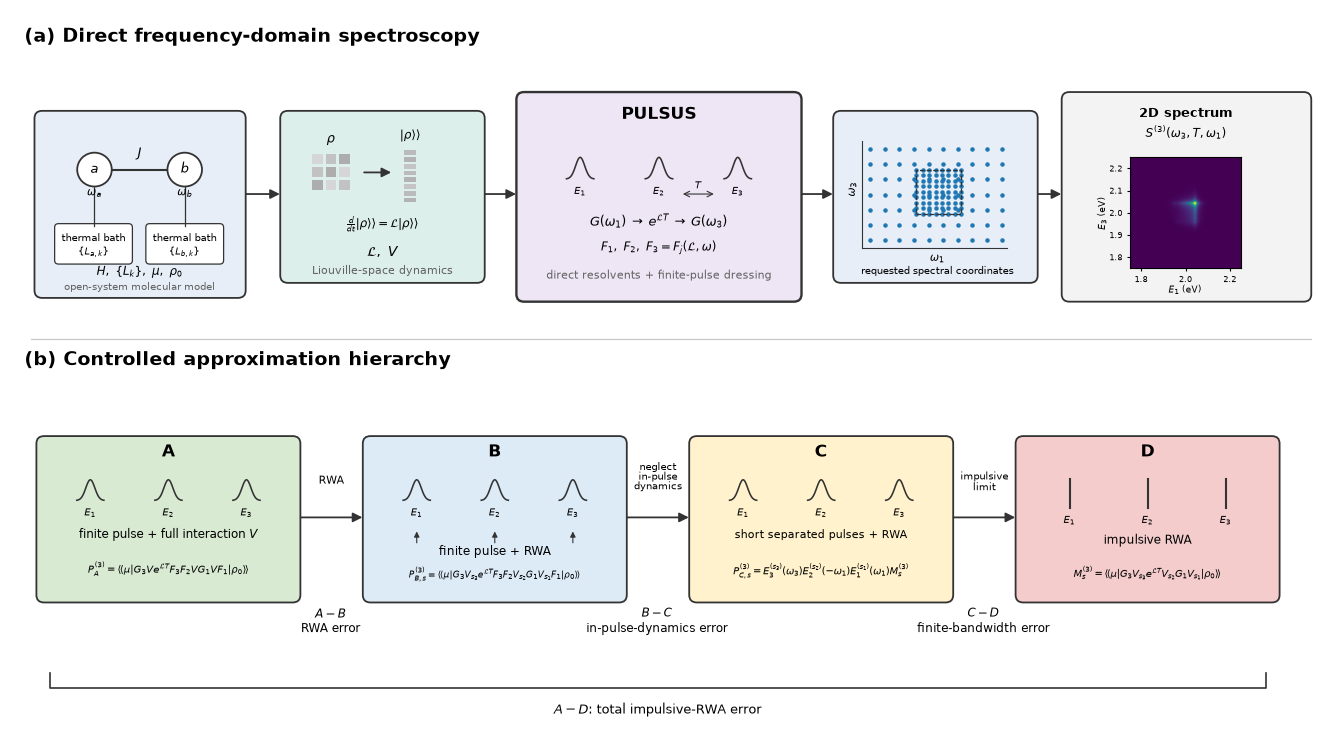

In [7]:
# ============================================================
# Figure 1 — Graphical PULSUS overview
# Revised spacing, spectrum box, and equation sizes
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Rectangle,
)


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(13.8, 7.8)
)

ax = fig.add_axes(
    [0.02, 0.03, 0.96, 0.94]
)

ax.set_xlim(0, 13.8)
ax.set_ylim(0, 7.8)
ax.axis("off")


# ============================================================
# Colors
# ============================================================

edge = "0.20"
muted = "0.38"

c_model = "#E7EEF7"
c_liouville = "#DDEFEA"
c_pulsus = "#EEE6F5"
c_sampling = "#E7EEF7"
c_spectrum = "#F3F3F3"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"

sampling_blue = "C0"


# ============================================================
# Helpers
# ============================================================

def rounded_box(
    x,
    y,
    w,
    h,
    facecolor,
    linewidth=1.3,
    radius=0.08,
):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            f"round,pad=0.025,"
            f"rounding_size={radius}"
        ),
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=linewidth,
    )

    ax.add_patch(patch)

    return patch


def arrow(
    x1,
    y1,
    x2,
    y2,
):

    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.3,
        color=edge,
    )

    ax.add_patch(patch)


def draw_three_pulses(
    x0,
    y0,
    width,
    height,
    pulse_width=0.022,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    x_local = np.linspace(
        -3,
        3,
        120,
    )

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
            + pulse_width
            * width
            * x_local
        )

        yy = (
            y0
            + height
            * np.exp(
                -0.5 * x_local**2
            )
        )

        ax.plot(
            xx,
            yy,
            color=edge,
            linewidth=1.15,
        )

        ax.text(
            x0 + center * width,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )

    return centers


def draw_impulses(
    x0,
    y0,
    width,
    height,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
        )

        ax.plot(
            [xx, xx],
            [
                y0,
                y0 + height,
            ],
            color=edge,
            linewidth=1.5,
        )

        ax.text(
            xx,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )


# ============================================================
# PANEL (a)
# ============================================================

ax.text(
    0.15,
    7.46,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# 1. Open-system molecular model
# ============================================================

# Slightly taller/lower box so all text stays inside
rounded_box(
    0.28,
    4.76,
    2.15,
    1.94,
    c_model,
)

site_y = 6.10


# ------------------------------------------------------------
# Subsystems a and b
# ------------------------------------------------------------

ax.add_patch(
    Circle(
        (0.88, site_y),
        0.18,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.add_patch(
    Circle(
        (1.82, site_y),
        0.18,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.text(
    0.88,
    site_y,
    r"$a$",
    ha="center",
    va="center",
    fontsize=9,
)

ax.text(
    1.82,
    site_y,
    r"$b$",
    ha="center",
    va="center",
    fontsize=9,
)


# ------------------------------------------------------------
# Coupling J
# ------------------------------------------------------------

ax.plot(
    [1.06, 1.64],
    [site_y, site_y],
    color=edge,
    linewidth=1.5,
)

ax.text(
    1.35,
    6.23,
    r"$J$",
    ha="center",
    fontsize=9,
)

ax.text(
    0.88,
    5.82,
    r"$\omega_a$",
    ha="center",
    fontsize=8.2,
)

ax.text(
    1.82,
    5.82,
    r"$\omega_b$",
    ha="center",
    fontsize=8.2,
)


# ------------------------------------------------------------
# Independent thermal baths
# ------------------------------------------------------------

bath_w = 0.76
bath_h = 0.38

rounded_box(
    0.49,
    5.12,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

rounded_box(
    1.44,
    5.12,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

ax.plot(
    [0.88, 0.88],
    [5.92, 5.50],
    color=edge,
    linewidth=0.9,
)

ax.plot(
    [1.82, 1.82],
    [5.92, 5.50],
    color=edge,
    linewidth=0.9,
)

ax.text(
    0.87,
    5.37,
    "thermal bath",
    ha="center",
    va="center",
    fontsize=6.9,
)

ax.text(
    0.87,
    5.22,
    r"$\{L_{a,k}\}$",
    ha="center",
    va="center",
    fontsize=7.3,
)

ax.text(
    1.82,
    5.37,
    "thermal bath",
    ha="center",
    va="center",
    fontsize=6.9,
)

ax.text(
    1.82,
    5.22,
    r"$\{L_{b,k}\}$",
    ha="center",
    va="center",
    fontsize=7.3,
)


# ------------------------------------------------------------
# Model labels, now safely inside box
# ------------------------------------------------------------

ax.text(
    1.35,
    4.98,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    1.35,
    4.82,
    "open-system molecular model",
    ha="center",
    fontsize=7.5,
    color=muted,
)


arrow(
    2.43,
    5.84,
    2.84,
    5.84,
)


# ============================================================
# 2. Liouville-space representation
# ============================================================

rounded_box(
    2.84,
    4.92,
    2.08,
    1.78,
    c_liouville,
)

rho_x = 3.15
rho_y = 5.88

for i in range(3):

    for j in range(3):

        shade = (
            0.68
            + 0.08
            * ((i + 2 * j) % 3)
        )

        ax.add_patch(
            Rectangle(
                (
                    rho_x + 0.14 * j,
                    rho_y + 0.14 * i,
                ),
                0.11,
                0.11,
                facecolor=str(shade),
                edgecolor="none",
            )
        )

ax.text(
    3.34,
    6.39,
    r"$\rho$",
    ha="center",
    fontsize=9,
)

arrow(
    3.66,
    6.07,
    4.00,
    6.07,
)

for i in range(8):

    ax.add_patch(
        Rectangle(
            (
                4.10,
                5.75 + 0.072 * i,
            ),
            0.13,
            0.052,
            facecolor=str(
                0.70
                + 0.035 * (i % 3)
            ),
            edgecolor="none",
        )
    )

ax.text(
    4.17,
    6.42,
    r"$|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    3.88,
    5.48,
    r"$\frac{d}{dt}|\rho\rangle\rangle"
    r"=\mathcal{L}|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.3,
)

ax.text(
    3.88,
    5.18,
    r"$\mathcal{L},\ V$",
    ha="center",
    fontsize=9.8,
)

ax.text(
    3.88,
    4.99,
    "Liouville-space dynamics",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    4.92,
    5.84,
    5.30,
    5.84,
)


# ============================================================
# 3. PULSUS
# ============================================================

rounded_box(
    5.30,
    4.72,
    2.92,
    2.18,
    c_pulsus,
    linewidth=1.7,
)

ax.text(
    6.76,
    6.64,
    "PULSUS",
    ha="center",
    fontsize=12.5,
    weight="bold",
)

pulse_x0 = 5.68
pulse_y0 = 6.00
pulse_width = 2.16

pulse_centers = draw_three_pulses(
    pulse_x0,
    pulse_y0,
    pulse_width,
    0.23,
)

x2 = (
    pulse_x0
    + pulse_centers[1] * pulse_width
)

x3 = (
    pulse_x0
    + pulse_centers[2] * pulse_width
)

T_left = x2 + 0.22
T_right = x3 - 0.22

ax.annotate(
    "",
    xy=(T_right, 5.84),
    xytext=(T_left, 5.84),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=0.8,
        color=edge,
    ),
)

ax.text(
    (T_left + T_right) / 2,
    5.87,
    r"$T$",
    ha="center",
    va="bottom",
    fontsize=7.5,
)

ax.text(
    6.76,
    5.50,
    r"$G(\omega_1)"
    r"\;\rightarrow\;"
    r"e^{\mathcal{L}T}"
    r"\;\rightarrow\;"
    r"G(\omega_3)$",
    ha="center",
    fontsize=9.1,
)

ax.text(
    6.76,
    5.23,
    r"$F_1,\ F_2,\ F_3"
    r"=F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.6,
)

ax.text(
    6.76,
    4.94,
    "direct resolvents + finite-pulse dressing",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    8.22,
    5.84,
    8.60,
    5.84,
)


# ============================================================
# 4. Requested spectral coordinates
# ============================================================

rounded_box(
    8.60,
    4.92,
    2.08,
    1.78,
    c_sampling,
)

grid_x0 = 8.88
grid_x1 = 10.39

grid_y0 = 5.27
grid_y1 = 6.40

ax.plot(
    [grid_x0, grid_x1],
    [grid_y0, grid_y0],
    color=edge,
    linewidth=0.8,
)

ax.plot(
    [grid_x0, grid_x0],
    [grid_y0, grid_y1],
    color=edge,
    linewidth=0.8,
)

ax.text(
    9.66,
    5.13,
    r"$\omega_1$",
    ha="center",
    fontsize=7.8,
)

ax.text(
    8.77,
    5.84,
    r"$\omega_3$",
    ha="center",
    rotation=90,
    fontsize=7.8,
)


# coarse points
x_coarse = np.linspace(
    8.96,
    10.33,
    10,
)

y_coarse = np.linspace(
    5.35,
    6.32,
    7,
)

Xc, Yc = np.meshgrid(
    x_coarse,
    y_coarse,
)

ax.scatter(
    Xc.ravel(),
    Yc.ravel(),
    s=5.0,
    color=sampling_blue,
)


# denser region
x_dense = np.linspace(
    9.44,
    9.91,
    8,
)

y_dense = np.linspace(
    5.63,
    6.10,
    9,
)

Xd, Yd = np.meshgrid(
    x_dense,
    y_dense,
)

ax.scatter(
    Xd.ravel(),
    Yd.ravel(),
    s=5.0,
    color=sampling_blue,
)

ax.add_patch(
    Rectangle(
        (
            9.44,
            5.63,
        ),
        0.47,
        0.47,
        fill=False,
        linestyle="--",
        linewidth=0.9,
        edgecolor=edge,
    )
)

ax.text(
    9.66,
    4.99,
    "requested spectral coordinates",
    ha="center",
    fontsize=7.5,
)


arrow(
    10.68,
    5.84,
    10.98,
    5.84,
)


# ============================================================
# 5. 2D spectrum
# ============================================================

rounded_box(
    10.98,
    4.72,
    2.55,
    2.18,
    c_spectrum,
)

ax.text(
    12.25,
    6.66,
    "2D spectrum",
    ha="center",
    fontsize=9.6,
    weight="bold",
)

ax.text(
    12.25,
    6.44,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=8.6,
)


# ------------------------------------------------------------
# Spectrum inset INSIDE the surrounding box
# ------------------------------------------------------------

ax_spec = ax.inset_axes(
    [
        11.27,
        5.05,
        1.95,
        1.18,
    ],
    transform=ax.transData,
)

ax_spec.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax_spec.set_xlabel(
    r"$E_1$ (eV)",
    fontsize=6.8,
    labelpad=1,
)

ax_spec.set_ylabel(
    r"$E_3$ (eV)",
    fontsize=6.8,
    labelpad=1,
)

ax_spec.tick_params(
    labelsize=5.8,
    length=2,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [0.22, 13.55],
    [4.30, 4.30],
    linewidth=0.85,
    color="0.78",
)


# ============================================================
# PANEL (b)
# ============================================================

ax.text(
    0.15,
    4.02,
    "(b) Controlled approximation hierarchy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# Model boxes
# ============================================================

box_y = 1.52
box_h = 1.72
box_w = 2.70

xA = 0.30
xB = 3.70
xC = 7.10
xD = 10.50


# ============================================================
# A
# ============================================================

rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    c_A,
)

ax.text(
    xA + box_w / 2,
    3.04,
    r"$\mathbf{A}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xA + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

ax.text(
    xA + box_w / 2,
    2.18,
    r"finite pulse + full interaction $V$",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xA + box_w / 2,
    1.81,
    r"$P_A^{(3)}="
    r"\langle\!\langle\mu|G_3Ve^{\mathcal{L}T}"
    r"F_3F_2VG_1VF_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=7.3,
)


# ============================================================
# B
# ============================================================

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    c_B,
)

ax.text(
    xB + box_w / 2,
    3.04,
    r"$\mathbf{B}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

centers_B = draw_three_pulses(
    xB + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

for center in centers_B:

    xx = (
        xB
        + 0.28
        + center
        * (box_w - 0.56)
    )

    ax.annotate(
        "",
        xy=(xx, 2.28),
        xytext=(xx, 2.10),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.8,
            color=edge,
        ),
    )

ax.text(
    xB + box_w / 2,
    2.00,
    "finite pulse + RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xB + box_w / 2,
    1.75,
    r"$P_{B,s}^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"F_3F_2V_{s_2}G_1V_{s_1}F_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=6.8,
)


# ============================================================
# C
# ============================================================

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    c_C,
)

ax.text(
    xC + box_w / 2,
    3.04,
    r"$\mathbf{C}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xC + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

ax.text(
    xC + box_w / 2,
    2.18,
    "short separated pulses + RWA",
    ha="center",
    fontsize=8.1,
)

ax.text(
    xC + box_w / 2,
    1.79,
    r"$P_{C,s}^{(3)}="
    r"E_3^{(s_3)}(\omega_3)"
    r"E_2^{(s_2)}(-\omega_1)"
    r"E_1^{(s_1)}(\omega_1)"
    r"M_s^{(3)}$",
    ha="center",
    fontsize=7.0,
)


# ============================================================
# D
# ============================================================

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    c_D,
)

ax.text(
    xD + box_w / 2,
    3.04,
    r"$\mathbf{D}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_impulses(
    xD + 0.28,
    2.50,
    box_w - 0.56,
    0.31,
)

ax.text(
    xD + box_w / 2,
    2.12,
    "impulsive RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xD + box_w / 2,
    1.76,
    r"$M_s^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"V_{s_2}G_1V_{s_1}|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=7.0,
)


# ============================================================
# Approximation arrows
# ============================================================

arrow(
    xA + box_w,
    2.40,
    xB,
    2.40,
)

arrow(
    xB + box_w,
    2.40,
    xC,
    2.40,
)

arrow(
    xC + box_w,
    2.40,
    xD,
    2.40,
)


# ------------------------------------------------------------
# Approximation labels
# ------------------------------------------------------------

ax.text(
    (
        xA + box_w + xB
    ) / 2,
    2.73,
    "RWA",
    ha="center",
    va="bottom",
    fontsize=8.2,
)

ax.text(
    (
        xB + box_w + xC
    ) / 2,
    2.68,
    "neglect\nin-pulse\ndynamics",
    ha="center",
    va="bottom",
    fontsize=7.3,
    linespacing=0.95,
)

ax.text(
    (
        xC + box_w + xD
    ) / 2,
    2.68,
    "impulsive\nlimit",
    ha="center",
    va="bottom",
    fontsize=7.4,
    linespacing=0.95,
)


# ============================================================
# Error channels
# ============================================================

ax.text(
    3.34,
    1.18,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    fontsize=8.5,
)

ax.text(
    6.74,
    1.18,
    r"$B-C$"
    "\n"
    "in-pulse-dynamics error",
    ha="center",
    fontsize=8.3,
)

ax.text(
    10.14,
    1.18,
    r"$C-D$"
    "\n"
    "finite-bandwidth error",
    ha="center",
    fontsize=8.3,
)


# ============================================================
# Total A-D error
# ============================================================

y_bracket = 0.58

ax.plot(
    [
        xA + 0.12,
        xA + 0.12,
        xD + box_w - 0.12,
        xD + box_w - 0.12,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    0.31,
    r"$A-D$: total impulsive-RWA error",
    ha="center",
    fontsize=9.2,
)


plt.show()

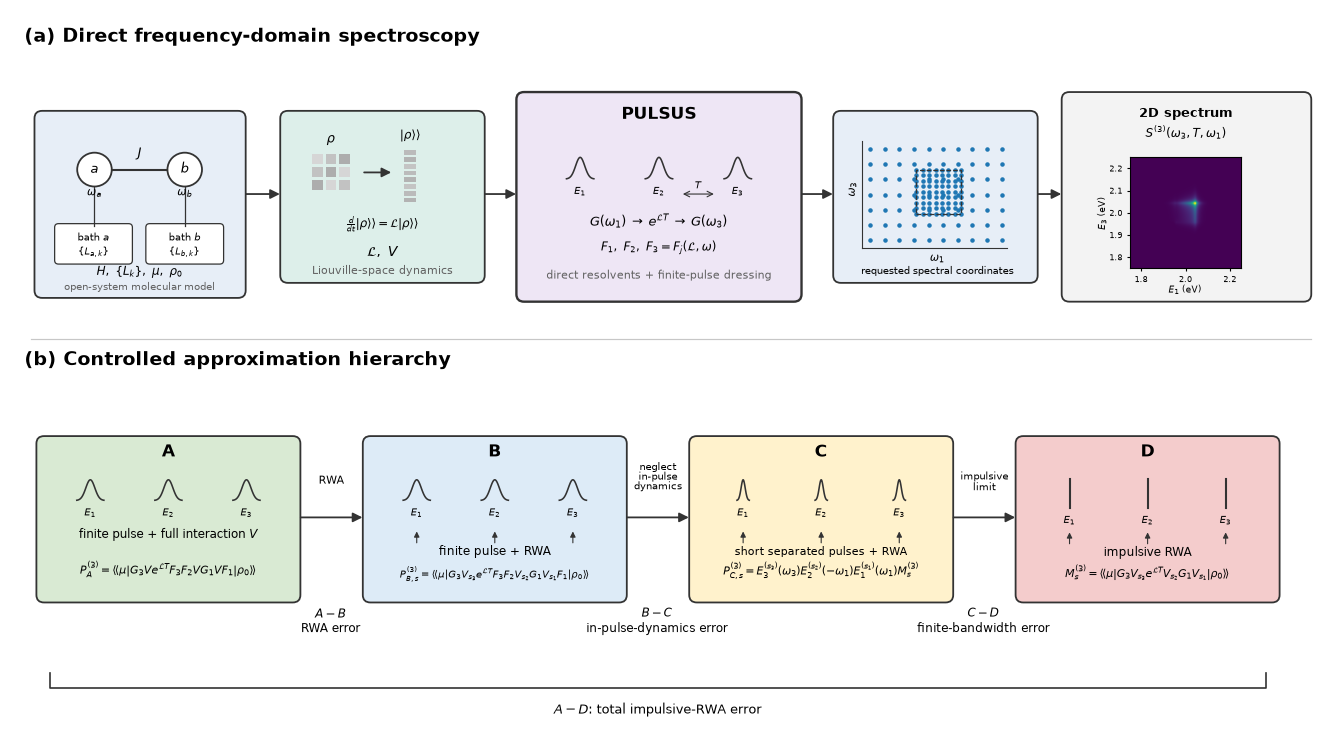

In [12]:
# ============================================================
# Figure 1 — Graphical PULSUS overview
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
    Rectangle,
)


# ============================================================
# Canvas
# ============================================================

fig = plt.figure(
    figsize=(13.8, 7.8)
)

ax = fig.add_axes(
    [0.02, 0.03, 0.96, 0.94]
)

ax.set_xlim(0, 13.8)
ax.set_ylim(0, 7.8)
ax.axis("off")


# ============================================================
# Colors
# ============================================================

edge = "0.20"
muted = "0.38"

c_model = "#E7EEF7"
c_liouville = "#DDEFEA"
c_pulsus = "#EEE6F5"
c_sampling = "#E7EEF7"
c_spectrum = "#F3F3F3"

c_A = "#D9EAD3"
c_B = "#DDEBF7"
c_C = "#FFF2CC"
c_D = "#F4CCCC"

sampling_blue = "C0"


# ============================================================
# Helpers
# ============================================================

def rounded_box(
    x,
    y,
    w,
    h,
    facecolor,
    linewidth=1.3,
    radius=0.08,
):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            f"round,pad=0.025,"
            f"rounding_size={radius}"
        ),
        facecolor=facecolor,
        edgecolor=edge,
        linewidth=linewidth,
    )

    ax.add_patch(patch)

    return patch


def arrow(
    x1,
    y1,
    x2,
    y2,
):

    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.3,
        color=edge,
    )

    ax.add_patch(patch)


def draw_three_pulses(
    x0,
    y0,
    width,
    height,
    pulse_width=0.022,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    x_local = np.linspace(
        -3,
        3,
        120,
    )

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
            + pulse_width
            * width
            * x_local
        )

        yy = (
            y0
            + height
            * np.exp(
                -0.5 * x_local**2
            )
        )

        ax.plot(
            xx,
            yy,
            color=edge,
            linewidth=1.15,
        )

        ax.text(
            x0 + center * width,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )

    return centers


def draw_impulses(
    x0,
    y0,
    width,
    height,
):

    centers = [
        0.12,
        0.50,
        0.88,
    ]

    for i, center in enumerate(centers):

        xx = (
            x0
            + center * width
        )

        ax.plot(
            [xx, xx],
            [
                y0,
                y0 + height,
            ],
            color=edge,
            linewidth=1.5,
        )

        ax.text(
            xx,
            y0 - 0.08,
            rf"$E_{i+1}$",
            ha="center",
            va="top",
            fontsize=7.3,
        )


# ============================================================
# PANEL (a)
# ============================================================

ax.text(
    0.15,
    7.46,
    "(a) Direct frequency-domain spectroscopy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# 1. Open-system molecular model
# ============================================================

rounded_box(
    0.28,
    4.76,
    2.15,
    1.94,
    c_model,
)

site_y = 6.10


# ------------------------------------------------------------
# Subsystems a and b
# ------------------------------------------------------------

ax.add_patch(
    Circle(
        (0.88, site_y),
        0.18,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.add_patch(
    Circle(
        (1.82, site_y),
        0.18,
        facecolor="white",
        edgecolor=edge,
        linewidth=1.3,
    )
)

ax.text(
    0.88,
    site_y,
    r"$a$",
    ha="center",
    va="center",
    fontsize=9,
)

ax.text(
    1.82,
    site_y,
    r"$b$",
    ha="center",
    va="center",
    fontsize=9,
)


# ------------------------------------------------------------
# Coupling J
# ------------------------------------------------------------

ax.plot(
    [1.06, 1.64],
    [site_y, site_y],
    color=edge,
    linewidth=1.5,
)

ax.text(
    1.35,
    6.23,
    r"$J$",
    ha="center",
    fontsize=9,
)

ax.text(
    0.88,
    5.82,
    r"$\omega_a$",
    ha="center",
    fontsize=8.2,
)

ax.text(
    1.82,
    5.82,
    r"$\omega_b$",
    ha="center",
    fontsize=8.2,
)


# ------------------------------------------------------------
# Independent baths
# ------------------------------------------------------------

bath_w = 0.76
bath_h = 0.38

rounded_box(
    0.49,
    5.12,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

rounded_box(
    1.44,
    5.12,
    bath_w,
    bath_h,
    "white",
    linewidth=0.9,
    radius=0.04,
)

ax.plot(
    [0.88, 0.88],
    [5.92, 5.50],
    color=edge,
    linewidth=0.9,
)

ax.plot(
    [1.82, 1.82],
    [5.92, 5.50],
    color=edge,
    linewidth=0.9,
)

ax.text(
    0.87,
    5.37,
    "bath $a$",
    ha="center",
    va="center",
    fontsize=7.1,
)

ax.text(
    0.87,
    5.22,
    r"$\{L_{a,k}\}$",
    ha="center",
    va="center",
    fontsize=7.3,
)

ax.text(
    1.82,
    5.37,
    "bath $b$",
    ha="center",
    va="center",
    fontsize=7.1,
)

ax.text(
    1.82,
    5.22,
    r"$\{L_{b,k}\}$",
    ha="center",
    va="center",
    fontsize=7.3,
)


ax.text(
    1.35,
    4.98,
    r"$H,\ \{L_k\},\ \mu,\ \rho_0$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    1.35,
    4.82,
    "open-system molecular model",
    ha="center",
    fontsize=7.5,
    color=muted,
)


arrow(
    2.43,
    5.84,
    2.84,
    5.84,
)


# ============================================================
# 2. Liouville-space representation
# ============================================================

rounded_box(
    2.84,
    4.92,
    2.08,
    1.78,
    c_liouville,
)

rho_x = 3.15
rho_y = 5.88

for i in range(3):

    for j in range(3):

        shade = (
            0.68
            + 0.08
            * ((i + 2 * j) % 3)
        )

        ax.add_patch(
            Rectangle(
                (
                    rho_x + 0.14 * j,
                    rho_y + 0.14 * i,
                ),
                0.11,
                0.11,
                facecolor=str(shade),
                edgecolor="none",
            )
        )

ax.text(
    3.34,
    6.39,
    r"$\rho$",
    ha="center",
    fontsize=9,
)

arrow(
    3.66,
    6.07,
    4.00,
    6.07,
)

for i in range(8):

    ax.add_patch(
        Rectangle(
            (
                4.10,
                5.75 + 0.072 * i,
            ),
            0.13,
            0.052,
            facecolor=str(
                0.70
                + 0.035 * (i % 3)
            ),
            edgecolor="none",
        )
    )

ax.text(
    4.17,
    6.42,
    r"$|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.5,
)

ax.text(
    3.88,
    5.48,
    r"$\frac{d}{dt}|\rho\rangle\rangle"
    r"=\mathcal{L}|\rho\rangle\rangle$",
    ha="center",
    fontsize=8.3,
)

ax.text(
    3.88,
    5.18,
    r"$\mathcal{L},\ V$",
    ha="center",
    fontsize=9.8,
)

ax.text(
    3.88,
    4.99,
    "Liouville-space dynamics",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    4.92,
    5.84,
    5.30,
    5.84,
)


# ============================================================
# 3. PULSUS
# ============================================================

rounded_box(
    5.30,
    4.72,
    2.92,
    2.18,
    c_pulsus,
    linewidth=1.7,
)

ax.text(
    6.76,
    6.64,
    "PULSUS",
    ha="center",
    fontsize=12.5,
    weight="bold",
)

pulse_x0 = 5.68
pulse_y0 = 6.00
pulse_width = 2.16

pulse_centers = draw_three_pulses(
    pulse_x0,
    pulse_y0,
    pulse_width,
    0.23,
)

x2 = (
    pulse_x0
    + pulse_centers[1] * pulse_width
)

x3 = (
    pulse_x0
    + pulse_centers[2] * pulse_width
)

T_left = x2 + 0.22
T_right = x3 - 0.22

ax.annotate(
    "",
    xy=(T_right, 5.84),
    xytext=(T_left, 5.84),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=0.8,
        color=edge,
    ),
)

ax.text(
    (T_left + T_right) / 2,
    5.87,
    r"$T$",
    ha="center",
    va="bottom",
    fontsize=7.5,
)

ax.text(
    6.76,
    5.50,
    r"$G(\omega_1)"
    r"\;\rightarrow\;"
    r"e^{\mathcal{L}T}"
    r"\;\rightarrow\;"
    r"G(\omega_3)$",
    ha="center",
    fontsize=9.1,
)

ax.text(
    6.76,
    5.23,
    r"$F_1,\ F_2,\ F_3"
    r"=F_j(\mathcal{L},\omega)$",
    ha="center",
    fontsize=8.6,
)

ax.text(
    6.76,
    4.94,
    "direct resolvents + finite-pulse dressing",
    ha="center",
    fontsize=7.8,
    color=muted,
)


arrow(
    8.22,
    5.84,
    8.60,
    5.84,
)


# ============================================================
# 4. Requested spectral coordinates
# ============================================================

rounded_box(
    8.60,
    4.92,
    2.08,
    1.78,
    c_sampling,
)

grid_x0 = 8.88
grid_x1 = 10.39

grid_y0 = 5.27
grid_y1 = 6.40

ax.plot(
    [grid_x0, grid_x1],
    [grid_y0, grid_y0],
    color=edge,
    linewidth=0.8,
)

ax.plot(
    [grid_x0, grid_x0],
    [grid_y0, grid_y1],
    color=edge,
    linewidth=0.8,
)

ax.text(
    9.66,
    5.13,
    r"$\omega_1$",
    ha="center",
    fontsize=7.8,
)

ax.text(
    8.77,
    5.84,
    r"$\omega_3$",
    ha="center",
    rotation=90,
    fontsize=7.8,
)

x_coarse = np.linspace(
    8.96,
    10.33,
    10,
)

y_coarse = np.linspace(
    5.35,
    6.32,
    7,
)

Xc, Yc = np.meshgrid(
    x_coarse,
    y_coarse,
)

ax.scatter(
    Xc.ravel(),
    Yc.ravel(),
    s=5.0,
    color=sampling_blue,
)

x_dense = np.linspace(
    9.44,
    9.91,
    8,
)

y_dense = np.linspace(
    5.63,
    6.10,
    9,
)

Xd, Yd = np.meshgrid(
    x_dense,
    y_dense,
)

ax.scatter(
    Xd.ravel(),
    Yd.ravel(),
    s=5.0,
    color=sampling_blue,
)

ax.add_patch(
    Rectangle(
        (
            9.44,
            5.63,
        ),
        0.47,
        0.47,
        fill=False,
        linestyle="--",
        linewidth=0.9,
        edgecolor=edge,
    )
)

ax.text(
    9.66,
    4.99,
    "requested spectral coordinates",
    ha="center",
    fontsize=7.5,
)


arrow(
    10.68,
    5.84,
    10.98,
    5.84,
)


# ============================================================
# 5. 2D spectrum
# ============================================================

rounded_box(
    10.98,
    4.72,
    2.55,
    2.18,
    c_spectrum,
)

ax.text(
    12.25,
    6.66,
    "2D spectrum",
    ha="center",
    fontsize=9.6,
    weight="bold",
)

ax.text(
    12.25,
    6.44,
    r"$S^{(3)}(\omega_3,T,\omega_1)$",
    ha="center",
    fontsize=8.6,
)

ax_spec = ax.inset_axes(
    [
        11.27,
        5.05,
        1.95,
        1.18,
    ],
    transform=ax.transData,
)

ax_spec.imshow(
    A_fig1,
    origin="lower",
    extent=[
        E1_fig1.min(),
        E1_fig1.max(),
        E3_fig1.min(),
        E3_fig1.max(),
    ],
    aspect="equal",
    vmin=0,
    vmax=1,
)

ax_spec.set_xlabel(
    r"$E_1$ (eV)",
    fontsize=6.8,
    labelpad=1,
)

ax_spec.set_ylabel(
    r"$E_3$ (eV)",
    fontsize=6.8,
    labelpad=1,
)

ax_spec.tick_params(
    labelsize=5.8,
    length=2,
)


# ============================================================
# Divider
# ============================================================

ax.plot(
    [0.22, 13.55],
    [4.30, 4.30],
    linewidth=0.85,
    color="0.78",
)


# ============================================================
# PANEL (b)
# ============================================================

ax.text(
    0.15,
    4.02,
    "(b) Controlled approximation hierarchy",
    fontsize=14,
    weight="bold",
    ha="left",
)


# ============================================================
# Model boxes
# ============================================================

box_y = 1.52
box_h = 1.72
box_w = 2.70

xA = 0.30
xB = 3.70
xC = 7.10
xD = 10.50


# ============================================================
# A
# ============================================================

rounded_box(
    xA,
    box_y,
    box_w,
    box_h,
    c_A,
)

ax.text(
    xA + box_w / 2,
    3.04,
    r"$\mathbf{A}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

draw_three_pulses(
    xA + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

ax.text(
    xA + box_w / 2,
    2.18,
    r"finite pulse + full interaction $V$",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xA + box_w / 2,
    1.80,
    r"$P_A^{(3)}="
    r"\langle\!\langle\mu|G_3Ve^{\mathcal{L}T}"
    r"F_3F_2VG_1VF_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=8.0,
)


# ============================================================
# B
# ============================================================

rounded_box(
    xB,
    box_y,
    box_w,
    box_h,
    c_B,
)

ax.text(
    xB + box_w / 2,
    3.04,
    r"$\mathbf{B}$",
    ha="center",
    fontsize=12,
    weight="bold",
)

centers_B = draw_three_pulses(
    xB + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
)

for center in centers_B:

    xx = (
        xB
        + 0.28
        + center
        * (box_w - 0.56)
    )

    ax.annotate(
        "",
        xy=(xx, 2.28),
        xytext=(xx, 2.10),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.8,
            color=edge,
        ),
    )

ax.text(
    xB + box_w / 2,
    2.00,
    "finite pulse + RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xB + box_w / 2,
    1.75,
    r"$P_{B,s}^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"F_3F_2V_{s_2}G_1V_{s_1}F_1|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=7.5,
)


# ============================================================
# C — short separated pulses + RWA
# ============================================================

rounded_box(
    xC,
    box_y,
    box_w,
    box_h,
    c_C,
)

ax.text(
    xC + box_w / 2,
    3.04,
    r"$\mathbf{C}$",
    ha="center",
    fontsize=12,
    weight="bold",
)


# ------------------------------------------------------------
# Narrower Gaussian pulses to represent the short-pulse limit
# ------------------------------------------------------------

centers_C = draw_three_pulses(
    xC + 0.28,
    2.58,
    box_w - 0.56,
    0.22,
    pulse_width=0.010,
)


# ------------------------------------------------------------
# RWA-selected interactions retained from Model B
# ------------------------------------------------------------

for center in centers_C:

    xx = (
        xC
        + 0.28
        + center
        * (box_w - 0.56)
    )

    ax.annotate(
        "",
        xy=(xx, 2.28),
        xytext=(xx, 2.10),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.8,
            color=edge,
        ),
    )


ax.text(
    xC + box_w / 2,
    2.00,
    "short separated pulses + RWA",
    ha="center",
    fontsize=8.1,
)


ax.text(
    xC + box_w / 2,
    1.79,
    r"$P_{C,s}^{(3)}="
    r"E_3^{(s_3)}(\omega_3)"
    r"E_2^{(s_2)}(-\omega_1)"
    r"E_1^{(s_1)}(\omega_1)"
    r"M_s^{(3)}$",
    ha="center",
    fontsize=7.8,
)


# ============================================================
# D — impulsive RWA
# ============================================================

rounded_box(
    xD,
    box_y,
    box_w,
    box_h,
    c_D,
)

ax.text(
    xD + box_w / 2,
    3.04,
    r"$\mathbf{D}$",
    ha="center",
    fontsize=12,
    weight="bold",
)


# ------------------------------------------------------------
# Impulsive pulses
# ------------------------------------------------------------

centers_D = [
    0.12,
    0.50,
    0.88,
]

for i, center in enumerate(centers_D):

    xx = (
        xD
        + 0.28
        + center
        * (box_w - 0.56)
    )

    # delta-like pulse
    ax.plot(
        [xx, xx],
        [
            2.50,
            2.81,
        ],
        color=edge,
        linewidth=1.5,
    )

    ax.text(
        xx,
        2.42,
        rf"$E_{i+1}$",
        ha="center",
        va="top",
        fontsize=7.3,
    )

    # RWA-selected interaction
    ax.annotate(
        "",
        xy=(xx, 2.27),
        xytext=(xx, 2.09),
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=0.8,
            color=edge,
        ),
    )


ax.text(
    xD + box_w / 2,
    1.99,
    "impulsive RWA",
    ha="center",
    fontsize=8.4,
)

ax.text(
    xD + box_w / 2,
    1.76,
    r"$M_s^{(3)}="
    r"\langle\!\langle\mu|G_3V_{s_3}e^{\mathcal{L}T}"
    r"V_{s_2}G_1V_{s_1}|\rho_0\rangle\!\rangle$",
    ha="center",
    fontsize=7.8,
)

# ============================================================
# Approximation arrows
# ============================================================

arrow(
    xA + box_w,
    2.40,
    xB,
    2.40,
)

arrow(
    xB + box_w,
    2.40,
    xC,
    2.40,
)

arrow(
    xC + box_w,
    2.40,
    xD,
    2.40,
)


# ------------------------------------------------------------
# Approximation labels
# ------------------------------------------------------------

ax.text(
    (
        xA + box_w + xB
    ) / 2,
    2.73,
    "RWA",
    ha="center",
    va="bottom",
    fontsize=8.2,
)

ax.text(
    (
        xB + box_w + xC
    ) / 2,
    2.68,
    "neglect\nin-pulse\ndynamics",
    ha="center",
    va="bottom",
    fontsize=7.3,
    linespacing=0.95,
)

ax.text(
    (
        xC + box_w + xD
    ) / 2,
    2.68,
    "impulsive\nlimit",
    ha="center",
    va="bottom",
    fontsize=7.4,
    linespacing=0.95,
)


# ============================================================
# Error channels
# ============================================================

ax.text(
    3.34,
    1.18,
    r"$A-B$"
    "\n"
    "RWA error",
    ha="center",
    fontsize=8.5,
)

ax.text(
    6.74,
    1.18,
    r"$B-C$"
    "\n"
    "in-pulse-dynamics error",
    ha="center",
    fontsize=8.3,
)

ax.text(
    10.14,
    1.18,
    r"$C-D$"
    "\n"
    "finite-bandwidth error",
    ha="center",
    fontsize=8.3,
)


# ============================================================
# Total A-D error
# ============================================================

y_bracket = 0.58

ax.plot(
    [
        xA + 0.12,
        xA + 0.12,
        xD + box_w - 0.12,
        xD + box_w - 0.12,
    ],
    [
        y_bracket + 0.16,
        y_bracket,
        y_bracket,
        y_bracket + 0.16,
    ],
    color=edge,
    linewidth=1.2,
)

ax.text(
    (
        xA
        + xD
        + box_w
    )
    / 2,
    0.31,
    r"$A-D$: total impulsive-RWA error",
    ha="center",
    fontsize=9.2,
)

figure_dir = Path(
    "../figures/01_method_workflow"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    figure_dir / "Figure01_method_workflow.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figure_dir / "Figure01_method_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()